# 📊 Student Stress Detection - Complete Analysis Pipeline

 Jana Alaa  


---

## 📋 Table of Contents

### Part 1: Setup & Data Understanding
1. [Problem Definition](#1-problem-definition)
2. [Library Imports & Configuration](#2-library-imports--configuration)
3. [Project Path Setup](#3-project-path-setup)
4. [Dataset Loading & Overview](#4-dataset-overview)

### Part 2: Data Cleaning & Preprocessing
5. [Duplicate Detection & Removal](#5-duplicate-detection)
6. [Missing Value Handling](#6-missing-value-handling)

### Part 3: Exploratory Data Analysis (EDA)
7. [Exploratory Data Analysis](#7-exploratory-data-analysis)
   - Histograms, Correlation Heatmap, Boxplots, Class Distribution, Pairplots, Scatter Plots

### Part 4: Data Preparation & Feature Engineering
8. [Train/Validation/Test Split (70/15/15)](#8-train-validation-test-split)
9. [Class Imbalance Handling](#9-class-imbalance-handling)

### Part 5: Model Training & Evaluation
10. [Baseline Machine Learning Models (10 Algorithms)](#10-baseline-machine-learning-models)
11. [Hyperparameter Tuning](#11-hyperparameter-tuning)
12. [Overfitting/Underfitting Analysis](#12-overfitting-underfitting-analysis)
13. [Comprehensive Model Evaluation](#13-comprehensive-model-evaluation)

### Part 6: Deep Learning
14. [Deep Learning Models (Tabular FNN + Emotion CNN)](#14-deep-learning-models)

### Part 7: Results & Deployment
15. [Results, Deployment & Future Work](#15-results-deployment-future-work)

---

## 🚀 How to Run This Notebook

### Prerequisites
```bash
pip install -r requirements.txt
```

### Execution Order
1. **Run all cells sequentially** from top to bottom
2. **Set flags** if needed:
   - `RUN_DEEP_LEARNING = True` to train neural networks (requires TensorFlow)
3. **Expected runtime**: ~30-60 minutes (CPU), ~10-20 minutes (GPU)

### Output Files
- **Models**: `artifacts/models/`
- **Figures**: `artifacts/figures/`
- **Metrics**: `artifacts/metrics/`
- **Report**: `report/project_steps.md`

---

# 1. Problem Definition

## 1.1 Project Objective
This project aims to build a **multimodal stress detection system** for students using both **tabular lifestyle data** and **facial emotion recognition** from images. The goal is to predict whether a student is experiencing stress and provide an interpretable probability score.

## 1.2 Problem Type
- **Primary Task:** Binary Classification (Stressed / Not Stressed)
- **Modality 1:** Tabular data classification using lifestyle features (study hours, sleep, GPA, etc.)
- **Modality 2:** Computer vision using emotion recognition from facial images
- **Integration:** Comparative multimodal analysis (without mandatory late-fusion inference)

## 1.3 Why This Problem Matters
Student stress is a critical mental health issue affecting academic performance, physical health, and overall well-being. Early detection enables:
- **Proactive intervention** by counselors and educators
- **Personalized support** based on lifestyle patterns and emotional states
- **Data-driven insights** for institutional mental health programs
- **Scalable monitoring** across large student populations

## 1.4 Technical Approach
1. **Student Lifestyle Dataset** (tabular): Machine Learning + Deep Learning (FNN)
2. **Student Emotion Dataset** (images): Deep Learning (CNN)
3. **Deployment Strategy**: Export best-performing artifacts for Streamlit inference

## 1.5 Output Goals
- Binary prediction: **Stressed** or **Not Stressed**
- Confidence score (probability between 0 and 1)
- Model comparison (ML vs DL)
- Streamlit deployment for real-time inference

---

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Library Imports & Configuration

This cell imports all necessary libraries for:
- **Data manipulation**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine Learning**: sklearn (preprocessing, models, metrics)
- **Statistical tests**: scipy
- **Utilities**: warnings, pathlib, json

**Note:** TensorFlow is imported later when needed for deep learning models.

---

In [2]:
# Resolve project root dynamically
ROOT = Path.cwd()

# Walk upward until we find the folder that contains 'preprocessing/'
# Handles running from report/, student_stress_detection/, or the workspace root
for _candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (_candidate / "preprocessing").exists():
        ROOT = _candidate
        break
    elif (_candidate / "student_stress_detection" / "preprocessing").exists():
        ROOT = _candidate / "student_stress_detection"
        break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from preprocessing.data_cleaning import (
    TARGET_COLUMN,
    load_dataset,
    explore_dataset,
    remove_duplicates,
    detect_missing_values,
    handle_missing_values,
    handle_outliers,
)
from preprocessing.feature_engineering import (
    BINARY_TARGET_COLUMN,
    add_binary_target,
    encode_categoricals,
    scale_features,
    select_features,
    handle_imbalance,
    plot_class_distribution,
    plot_learning_curve,
)
from models.ml_models import get_ml_models, fit_predict_model
from evaluation.metrics import (
    compute_classification_metrics,
    save_confusion_matrix,
    save_roc_curve,
    save_model_comparison,
)
from utils.helpers import get_default_paths, save_json, save_joblib

paths = get_default_paths()
FIG_DIR = paths["figures"]
MODEL_DIR = paths["models"]
METRIC_DIR = paths["metrics"]

print("Project root:", ROOT)
print("Lifestyle CSV:", paths["lifestyle_csv"])
print("Emotion dataset:", paths["emotion_dir"])

Project root: c:\Users\AlexStore\Downloads\student stress detection amit project\student_stress_detection
Lifestyle CSV: C:\Users\AlexStore\Downloads\student stress detection amit project\student_stress_detection\datasets\student_lifestyle.csv
Emotion dataset: C:\Users\AlexStore\Downloads\student stress detection amit project\student_stress_detection\datasets\emotion_images


# 3. Project Path Setup

This cell configures the project directory structure and imports custom modules:

**Purpose:**
- Dynamically detect project root directory
- Import preprocessing, modeling, and utility functions
- Set up paths for datasets, models, and output figures

**Output directories:**
- `artifacts/models/` - Saved model files
- `artifacts/figures/` - Visualization outputs
- `artifacts/metrics/` - Performance metrics JSON
- `datasets/` - Raw and processed data

---

# 4. Dataset Loading & Overview

This section loads and explores the **Student Lifestyle Dataset** to understand its structure, content, and quality.

## What We'll Examine:
- **Dataset shape:** Number of rows (samples) and columns (features)
- **Data types:** Numeric vs categorical features
- **Sample rows:** First few observations to understand data format
- **Summary statistics:** Mean, std, min, max, quartiles for numeric features
- **Feature availability:** Verify required features exist in the dataset

## Purpose:
Understanding the dataset structure is essential before any analysis. This initial exploration helps us:
1. Identify data quality issues early
2. Plan appropriate preprocessing strategies
3. Understand feature distributions and ranges
4. Verify data matches our expectations

---

In [3]:
df_raw = load_dataset(paths["lifestyle_csv"])
exploration = explore_dataset(df_raw)

print("Shape:", exploration["shape"])
print("\nData types:")
print(pd.Series(exploration["dtypes"]))
print("\nInfo summary:\n")
print(exploration["info"])

display(df_raw.head())
display(df_raw.describe(include="all").T.head(20))

# Feature availability check for target project inputs
required_features = [
    "Study_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "GPA",
]
available_features = [c for c in required_features if c in df_raw.columns]
print("Available required features:", available_features)
print("Target column found:", TARGET_COLUMN in df_raw.columns)

Shape: (2000, 8)

Data types:
Student_ID                           int64
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

Info summary:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   fl

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Study_Hours_Per_Day,2000.0,NaN,NaN,NaN,7.4758,1.423888,5.0,6.3,7.4,8.7,10.0
Extracurricular_Hours_Per_Day,2000.0,NaN,NaN,NaN,1.9901,1.155855,0.0,1.0,2.0,3.0,4.0
Sleep_Hours_Per_Day,2000.0,NaN,NaN,NaN,7.50125,1.460949,5.0,6.2,7.5,8.8,10.0
Social_Hours_Per_Day,2000.0,NaN,NaN,NaN,2.70455,1.688514,0.0,1.2,2.6,4.1,6.0
Physical_Activity_Hours_Per_Day,2000.0,NaN,NaN,NaN,4.3283,2.51411,0.0,2.4,4.1,6.1,13.0
GPA,2000.0,NaN,NaN,NaN,3.11596,0.298674,2.24,2.9,3.11,3.33,4.0
Stress_Level,2000,3,High,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Available required features: ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']
Target column found: True


# 5. Data Cleaning & Preprocessing

Data cleaning is critical for model performance. This section handles common data quality issues:

## Cleaning Pipeline:
1. **Duplicate Removal** — Identify and remove duplicate rows
2. **Missing Value Handling** — Detect and impute missing data
3. **Outlier Detection & Treatment** — Identify and handle extreme values
4. **Feature Scaling** — Standardize numeric features
5. **Categorical Encoding** — Convert categorical variables to numeric

Each subsection includes:
- ✅ Detection and quantification of the issue
- ✅ Visualization of the problem
- ✅ Application of appropriate solution
- ✅ Validation of results

---

## 5.1 Duplicate Detection & Removal

Duplicate rows detected: 0 (0.00%)
Duplicate keep strategy: first
Shape before: (2000, 8)
Shape after duplicate removal: (2000, 8)

No duplicate rows found — data is clean in this regard.


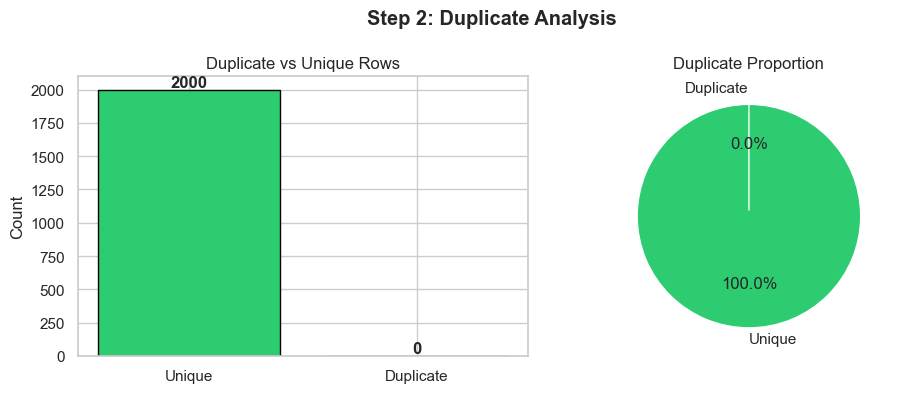


Per-column duplicate value counts:


,duplicate_values,dup_pct
Stress_Level,1997,99.85
Extracurricular_Hours_Per_Day,1959,97.95
Sleep_Hours_Per_Day,1949,97.45
Study_Hours_Per_Day,1949,97.45
Social_Hours_Per_Day,1939,96.95
Physical_Activity_Hours_Per_Day,1882,94.10
GPA,1842,92.10


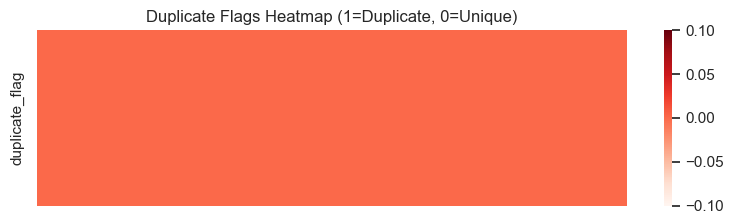

In [4]:
import inspect

dup_sig = inspect.signature(remove_duplicates)
if "keep" in dup_sig.parameters:
    dup_result = remove_duplicates(df_raw, keep="first")
else:
    dup_result = remove_duplicates(df_raw)

if isinstance(dup_result, tuple) and len(dup_result) == 3:
    df_no_dup, duplicate_count, duplicate_pct = dup_result
elif isinstance(dup_result, tuple) and len(dup_result) == 2:
    df_no_dup, duplicate_count = dup_result
    duplicate_pct = (duplicate_count / max(len(df_raw), 1)) * 100
else:
    raise ValueError("Unexpected return format from remove_duplicates")

print(f"Duplicate rows detected: {duplicate_count} ({duplicate_pct:.2f}%)")
print("Duplicate keep strategy: first")
print("Shape before:", df_raw.shape)
print("Shape after duplicate removal:", df_no_dup.shape)

# Show sample duplicate rows (if any)
if duplicate_count > 0:
    dup_mask = df_raw.duplicated(keep=False)
    dup_rows = df_raw[dup_mask].sort_values(by=list(df_raw.columns))
    print(f"\nSample duplicate rows (showing up to 10):")
    display(dup_rows.head(10))
else:
    print("\nNo duplicate rows found — data is clean in this regard.")

# Visualize duplicate status
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
dup_labels = ["Unique", "Duplicate"]
dup_counts = [len(df_raw) - duplicate_count, duplicate_count]
colors = ["#2ecc71", "#e74c3c"] if duplicate_count > 0 else ["#2ecc71", "#bdc3c7"]

axes[0].bar(dup_labels, dup_counts, color=colors, edgecolor="black")
axes[0].set_title("Duplicate vs Unique Rows")
axes[0].set_ylabel("Count")
for i, v in enumerate(dup_counts):
    axes[0].text(i, v + max(dup_counts) * 0.01, str(v), ha="center", fontweight="bold")

axes[1].pie(dup_counts, labels=dup_labels, autopct="%1.1f%%", colors=colors,
            startangle=90, explode=(0, 0.05))
axes[1].set_title("Duplicate Proportion")

plt.suptitle("Step 2: Duplicate Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG_DIR / "duplicate_analysis_nb.png"), dpi=150)
plt.show()

# Per-column duplicate value counts
col_dup_counts = {col: int(df_raw[col].duplicated().sum()) for col in df_raw.columns}
col_dup_df = pd.DataFrame.from_dict(col_dup_counts, orient="index", columns=["duplicate_values"])
col_dup_df["dup_pct"] = (col_dup_df["duplicate_values"] / len(df_raw) * 100).round(2)
col_dup_df = col_dup_df.sort_values("duplicate_values", ascending=False)
print("\nPer-column duplicate value counts:")
display(col_dup_df[col_dup_df["duplicate_values"] > 0])

# Duplicate flags heatmap (problem visualization requirement)
duplicate_flag_df = df_raw.assign(is_duplicate=df_raw.duplicated(keep=False).astype(int))[["is_duplicate"]]
plt.figure(figsize=(8, 2.4))
sns.heatmap(duplicate_flag_df.T, cmap="Reds", cbar=True, xticklabels=False, yticklabels=["duplicate_flag"])
plt.title("Duplicate Flags Heatmap (1=Duplicate, 0=Unique)")
plt.tight_layout()
plt.savefig(str(FIG_DIR / "duplicate_flags_heatmap_nb.png"), dpi=150)
plt.show()

## 5.2 Missing Value Handling

**Strategy:**
- Drop rows if missing percentage in a column is < 5%
- Impute using mean/median/mode based on distribution/type
- Compare imputation techniques (mean, median, KNN) using CV accuracy
- KNN fallback for remaining numeric missing values

**Why this matters:** Missing values can bias models or cause errors. Proper imputation preserves information while maintaining data quality.

**Next:** Run the code below to detect, visualize, compare strategies, and handle all missing values.

Columns with missing values: 0 / 8
Total missing cells: 0 / 16000


,missing_count,missing_percent



No missing values detected — dataset is complete.

Imputation strategy CV accuracy:
  mean: 0.9585
  median: 0.9585
  mode: 0.9585
  knn: 0.9585
Best imputation by CV: mean


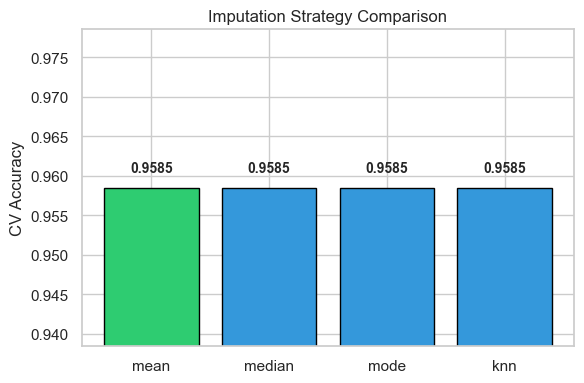


Missing-value strategy summary per column:
No missing-value operations were needed.

No columns had missing values — nothing to compare.

Shape after missing handling: (2000, 8)
Remaining total missing values: 0
VALIDATED: All missing values have been resolved.


In [5]:
# ---- Detect and display missing values ----
missing_df = detect_missing_values(df_no_dup)
missing_cols = missing_df[missing_df["missing_count"] > 0].sort_values("missing_percent", ascending=False)

print(f"Columns with missing values: {len(missing_cols)} / {len(df_no_dup.columns)}")
print(f"Total missing cells: {int(missing_df['missing_count'].sum())} / {df_no_dup.shape[0] * df_no_dup.shape[1]}")
display(missing_cols)

# ---- Data type breakdown of missing columns ----
if len(missing_cols) > 0:
    missing_col_names = missing_cols.index.tolist()
    dtype_info = pd.DataFrame({
        "column": missing_col_names,
        "dtype": [str(df_no_dup[c].dtype) for c in missing_col_names],
        "missing_count": [int(missing_cols.loc[c, "missing_count"]) for c in missing_col_names],
        "missing_pct": [float(missing_cols.loc[c, "missing_percent"]) for c in missing_col_names],
        "category": ["numeric" if pd.api.types.is_numeric_dtype(df_no_dup[c]) else "categorical" for c in missing_col_names],
    })
    print("\nMissing value breakdown by data type:")
    display(dtype_info)

    # ---- Bar chart of missing values per column ----
    fig, ax = plt.subplots(figsize=(max(8, len(missing_col_names) * 1.2), 5))
    bar_colors = ["#e74c3c" if pct >= 5 else "#f39c12" for pct in dtype_info["missing_pct"]]
    bars = ax.bar(dtype_info["column"], dtype_info["missing_pct"], color=bar_colors, edgecolor="black")
    ax.axhline(y=5, color="red", linestyle="--", alpha=0.7, label="5% threshold (drop vs impute)")
    ax.set_ylabel("Missing %")
    ax.set_title("Missing Values per Column")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    for bar, cnt in zip(bars, dtype_info["missing_count"]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f"n={cnt}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(str(FIG_DIR / "missing_values_bar_nb.png"), dpi=150)
    plt.show()
else:
    print("\nNo missing values detected — dataset is complete.")

# ---- Compare imputation strategies via CV accuracy ----
feature_candidates = [c for c in required_features if c in df_no_dup.columns]
if TARGET_COLUMN in df_no_dup.columns and feature_candidates:
    temp = df_no_dup[feature_candidates + [TARGET_COLUMN]].copy()
    temp[BINARY_TARGET_COLUMN] = temp[TARGET_COLUMN].astype(str).str.lower().map(
        lambda x: 1 if x in {"high", "moderate"} else 0
    )

    x_temp = temp[feature_candidates]
    y_temp = temp[BINARY_TARGET_COLUMN].astype(int).values

    scores = {}
    strategies = {
        "mean": SimpleImputer(strategy="mean"),
        "median": SimpleImputer(strategy="median"),
        "mode": SimpleImputer(strategy="most_frequent"),
        "knn": KNNImputer(n_neighbors=3),
    }

    for name, imputer in strategies.items():
        x_imp = imputer.fit_transform(x_temp)
        x_scaled = StandardScaler().fit_transform(x_imp)
        model = LogisticRegression(max_iter=2000)
        cv_score = cross_val_score(model, x_scaled, y_temp, cv=5, scoring="accuracy").mean()
        scores[name] = cv_score

    print("\nImputation strategy CV accuracy:")
    for k, v in scores.items():
        print(f"  {k}: {v:.4f}")
    best_imputation = max(scores, key=scores.get)
    print(f"Best imputation by CV: {best_imputation}")

    # Imputation comparison bar chart
    fig, ax = plt.subplots(figsize=(6, 4))
    strat_names = list(scores.keys())
    strat_vals = list(scores.values())
    bar_colors = ["#2ecc71" if n == best_imputation else "#3498db" for n in strat_names]
    ax.bar(strat_names, strat_vals, color=bar_colors, edgecolor="black")
    ax.set_ylabel("CV Accuracy")
    ax.set_title("Imputation Strategy Comparison")
    ax.set_ylim(min(strat_vals) - 0.02, max(strat_vals) + 0.02)
    for i, v in enumerate(strat_vals):
        ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)
    plt.tight_layout()
    plt.savefig(str(FIG_DIR / "imputation_comparison_nb.png"), dpi=150)
    plt.show()
else:
    print("Skipped imputation comparison (missing target/features).")

# ---- Apply production-grade missing handler (supports old/new signatures) ----
missing_result = handle_missing_values(df_no_dup)
if isinstance(missing_result, tuple) and len(missing_result) == 2:
    df_missing_handled, missing_strategy_summary = missing_result
else:
    df_missing_handled = missing_result
    missing_strategy_summary = {}
print("\nMissing-value strategy summary per column:")
print(missing_strategy_summary if missing_strategy_summary else "No missing-value operations were needed.")

# ---- Before vs After comparison ----
missing_before = detect_missing_values(df_no_dup)
missing_after = detect_missing_values(df_missing_handled)

comparison = pd.DataFrame({
    "before_missing": missing_before["missing_count"],
    "before_pct": missing_before["missing_percent"],
    "after_missing": missing_after["missing_count"],
    "after_pct": missing_after["missing_percent"],
})
comparison = comparison[comparison["before_missing"] > 0]

if len(comparison) > 0:
    print("\nBefore vs After missing value handling:")
    display(comparison)
else:
    print("\nNo columns had missing values — nothing to compare.")

print(f"\nShape after missing handling: {df_missing_handled.shape}")
print(f"Remaining total missing values: {int(df_missing_handled.isna().sum().sum())}")

# Final validation
remaining = int(df_missing_handled.isna().sum().sum())
if remaining == 0:
    print("VALIDATED: All missing values have been resolved.")
else:
    print(f"WARNING: {remaining} missing values still remain!")

## 5.3 Outlier Detection & Treatment

**Goal:** Identify extreme values that can distort models and summary statistics.

**Techniques Used:**
- **Z-score rule** (row-level): Flag rows where any numeric feature has |z| > 3
- **IQR rule** (feature-level): Compute Tukey fences (Q1-1.5×IQR, Q3+1.5×IQR)
- **Isolation Forest** (multivariate): Flag anomalous rows after IQR capping (contamination ≈ 3%)

**Outputs:**
- Per-feature outlier counts
- Before/after boxplots for most-affected features
- Row removal ratio (safety check)

**Note:** The actual cleaning uses the project pipeline `handle_outliers(df)` which applies IQR capping + Isolation Forest removal.

Numeric features considered: 6
Z-score outlier rows (any |z| > 3): 4
IQR outlier rows (any feature outside fences): 9
IQR outlier points (sum across features): 9
IsolationForest outlier rows (multivariate): 60


,feature,q1,q3,iqr,lower,upper,outlier_count,outlier_pct
0,Physical_Activity_Hours_Per_Day,2.4,6.10,3.70,-3.150,11.650,5,0.25
1,GPA,2.9,3.33,0.43,2.255,3.975,4,0.20
2,Study_Hours_Per_Day,6.3,8.70,2.40,2.700,12.300,0,0.00
3,Extracurricular_Hours_Per_Day,1.0,3.00,2.00,-2.000,6.000,0,0.00
4,Sleep_Hours_Per_Day,6.2,8.80,2.60,2.300,12.700,0,0.00
5,Social_Hours_Per_Day,1.2,4.10,2.90,-3.150,8.450,0,0.00


Outlier stats from pipeline: {'zscore': 4, 'iqr': 9, 'isolation_forest': 60, 'retained_percent': 0.10309278350515465}
Row removal ratio after outlier processing: 3.00%
Shape after outlier handling: (1940, 8)


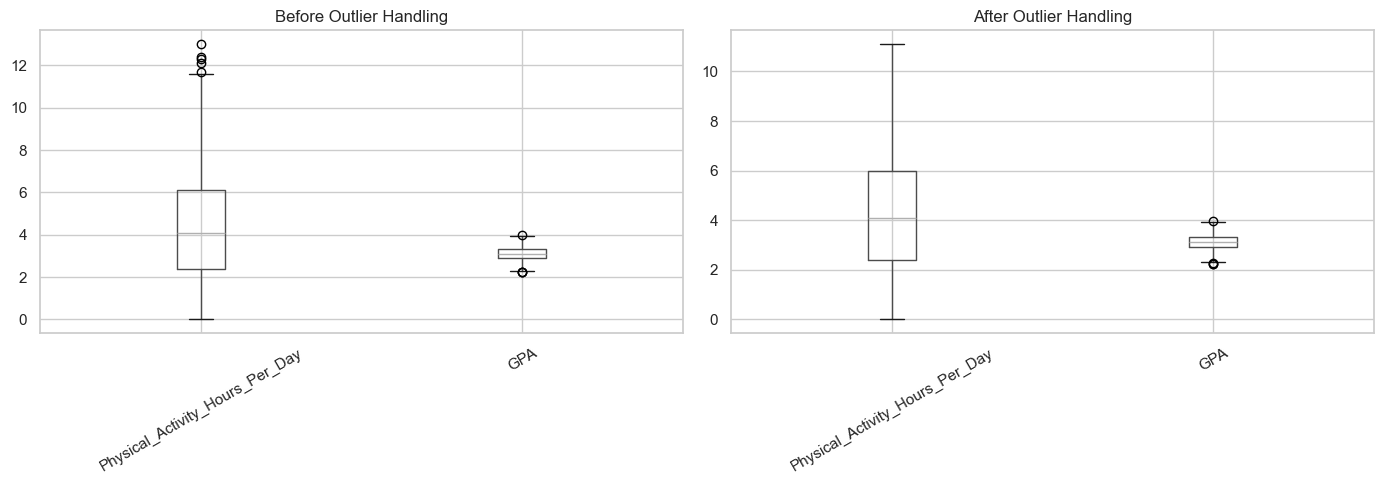

In [6]:
# Manual outlier diagnostics for reporting (more detailed than pipeline summary)
numeric_cols = [c for c in df_missing_handled.select_dtypes(include=[np.number]).columns if c != "Student_ID"]

if not numeric_cols:
    print("No numeric columns available for outlier detection.")
else:
    # ---- 1) Z-score (row-level) ----
    # Rows where ANY numeric feature is extreme
    z = np.abs(zscore(df_missing_handled[numeric_cols], nan_policy="omit"))
    z_outlier_rows = (z > 3).any(axis=1)
    z_outliers = int(z_outlier_rows.sum())

    # ---- 2) IQR (feature-level + row-level) ----
    iqr_rows_mask = np.zeros(len(df_missing_handled), dtype=bool)
    iqr_table_rows = []

    for c in numeric_cols:
        series = df_missing_handled[c]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        # Handle constant columns safely
        if pd.isna(iqr) or iqr == 0:
            lower, upper = q1, q3
            outlier_mask = pd.Series(False, index=series.index)
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outlier_mask = (series < lower) | (series > upper)

        outlier_count = int(outlier_mask.sum())
        outlier_pct = float(outlier_count / max(len(series), 1) * 100)

        iqr_rows_mask |= outlier_mask.to_numpy(dtype=bool)
        iqr_table_rows.append(
            {
                "feature": c,
                "q1": float(q1) if pd.notna(q1) else np.nan,
                "q3": float(q3) if pd.notna(q3) else np.nan,
                "iqr": float(iqr) if pd.notna(iqr) else np.nan,
                "lower": float(lower) if pd.notna(lower) else np.nan,
                "upper": float(upper) if pd.notna(upper) else np.nan,
                "outlier_count": outlier_count,
                "outlier_pct": outlier_pct,
            }
        )

    iqr_feature_table = pd.DataFrame(iqr_table_rows).sort_values(
        ["outlier_pct", "outlier_count"], ascending=False
    )

    iqr_outlier_points = int(iqr_feature_table["outlier_count"].sum())
    iqr_outlier_rows = int(iqr_rows_mask.sum())

    # ---- 3) Isolation Forest (multivariate, row-level) ----
    # Use a simple median fill just in case (should already be clean after missing handling)
    X_iso = df_missing_handled[numeric_cols].copy()
    X_iso = X_iso.fillna(X_iso.median(numeric_only=True))

    iso = IsolationForest(contamination=0.03, random_state=42)
    iso_labels = iso.fit_predict(X_iso)
    iso_outliers = int((iso_labels == -1).sum())

    # ---- Print a compact summary ----
    print(f"Numeric features considered: {len(numeric_cols)}")
    print(f"Z-score outlier rows (any |z| > 3): {z_outliers}")
    print(f"IQR outlier rows (any feature outside fences): {iqr_outlier_rows}")
    print(f"IQR outlier points (sum across features): {iqr_outlier_points}")
    print(f"IsolationForest outlier rows (multivariate): {iso_outliers}")

    # Show the most affected features
    top_iqr = iqr_feature_table.head(10).reset_index(drop=True)
    try:
        display(top_iqr)
    except Exception:
        print(top_iqr)

    # ---- Apply project outlier pipeline (IQR capping + IsolationForest removal) ----
    df_outlier_handled, outlier_stats = handle_outliers(df_missing_handled)
    removed_ratio = 1 - (len(df_outlier_handled) / max(len(df_missing_handled), 1))

    print("Outlier stats from pipeline:", outlier_stats)
    print(f"Row removal ratio after outlier processing: {removed_ratio*100:.2f}%")
    print("Shape after outlier handling:", df_outlier_handled.shape)

    # ---- Visual check: before vs after boxplots for most-affected features ----
    plot_cols = top_iqr.loc[top_iqr["outlier_count"] > 0, "feature"].tolist()[:6]
    if plot_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

        df_missing_handled[plot_cols].boxplot(ax=axes[0], rot=30)
        axes[0].set_title("Before Outlier Handling")

        df_outlier_handled[plot_cols].boxplot(ax=axes[1], rot=30)
        axes[1].set_title("After Outlier Handling")

        plt.tight_layout()
        plt.show()
    else:
        print("No IQR outliers detected in numeric features (nothing to plot).")

## How to interpret the outlier results (Z-score / IQR / Isolation Forest)

> This section is *diagnostic* (to understand the data) and *preprocessing* (to reduce the impact of extreme values on models).

- **Z-score (|z| > 3) — row-level**: flags rows where at least one numeric feature is unusually far from its mean (in standard-deviation units). Good when data is roughly normal. Sensitive to skewed distributions.
- **IQR fences (Q1−1.5×IQR, Q3+1.5×IQR) — feature-level**: flags values outside a robust range. Works well even when features are skewed. Note: **IQR outlier points** counts values, while **IQR outlier rows** counts rows affected by at least one feature.
- **Isolation Forest — multivariate row-level**: flags rows that are *globally unusual* across multiple features together (not just one extreme column). It can detect “weird combinations” even if each single feature looks fine.

### What action is taken in this notebook
- We apply the project pipeline `handle_outliers()` which does **IQR capping** (reduces extreme values without deleting rows) and then **removes a small fraction of rows** using Isolation Forest (here, contamination ≈ 3%).
- The printed **Row removal ratio** is a safety check: keeping it small avoids throwing away too much data and changing class balance.

### Practical guidance (what to write in your report)
- If **outliers are rare** and clearly erroneous (impossible values), removal is usually safe.
- If **outliers are frequent** (e.g., many points outside fences) but plausible, prefer **capping/winsorization** to keep information while stabilizing models.
- Always compute thresholds using the **training set only** in a real ML pipeline to avoid leakage (this notebook’s EDA section focuses on understanding and cleaning the full dataset before modeling).

# 6. Exploratory Data Analysis (EDA)

This section presents **7 key visualizations** to understand the data distribution, relationships, and potential issues before modeling.

## Visualizations Overview:
1. **Histograms/KDE** — Distribution shape for numeric features
2. **Missing Values Heatmap** — Visual pattern of missing data
3. **Correlation Heatmap** — Feature relationships and multicollinearity
4. **Boxplots** — Outlier detection and spread comparison
5. **Class Distribution** — Target balance check
6. **Pairplot** — Bivariate relationships between key features
7. **Scatter Plot** — Study vs Sleep hours colored by stress level

**Purpose:** Visual exploration helps identify patterns, relationships, and anomalies that guide feature engineering and model selection decisions.

---

Numeric columns for EDA: ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']
Total numeric features: 6


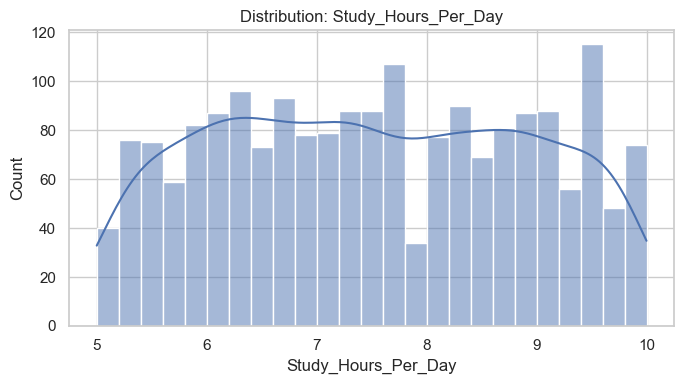

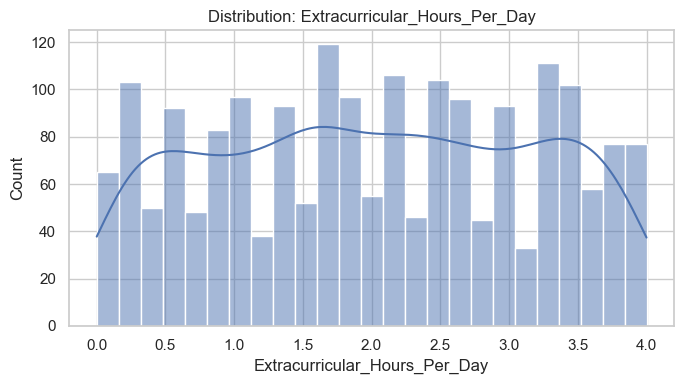

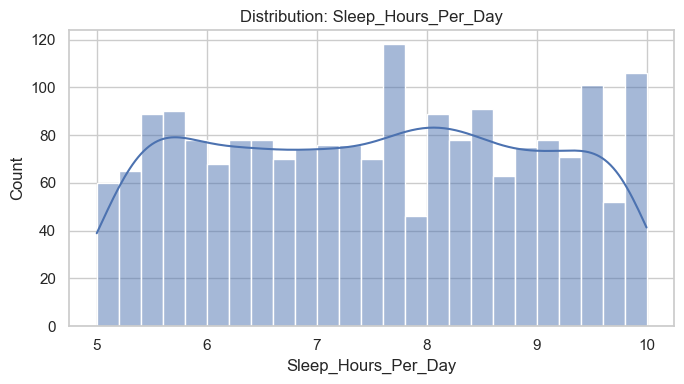

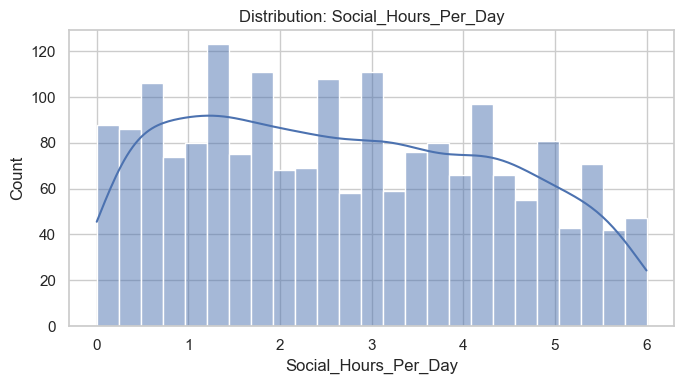

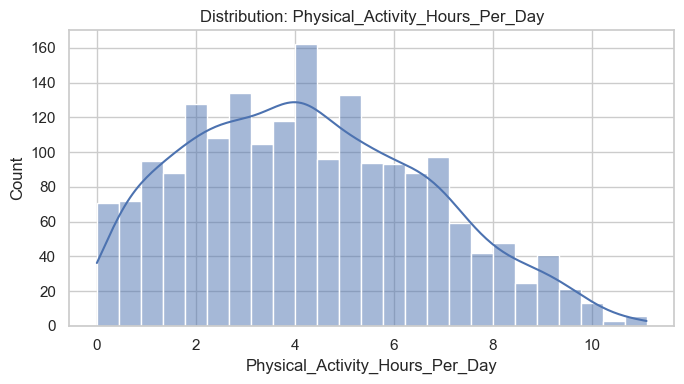

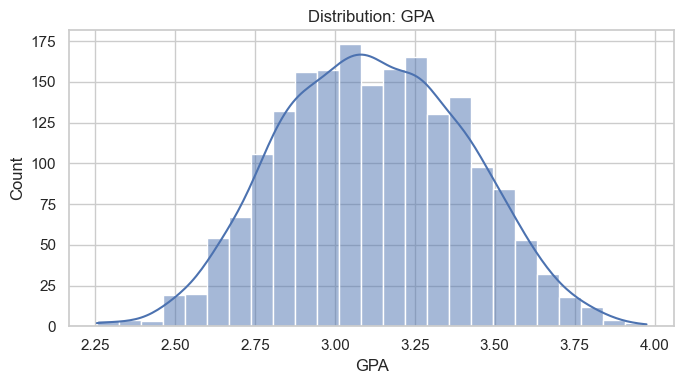

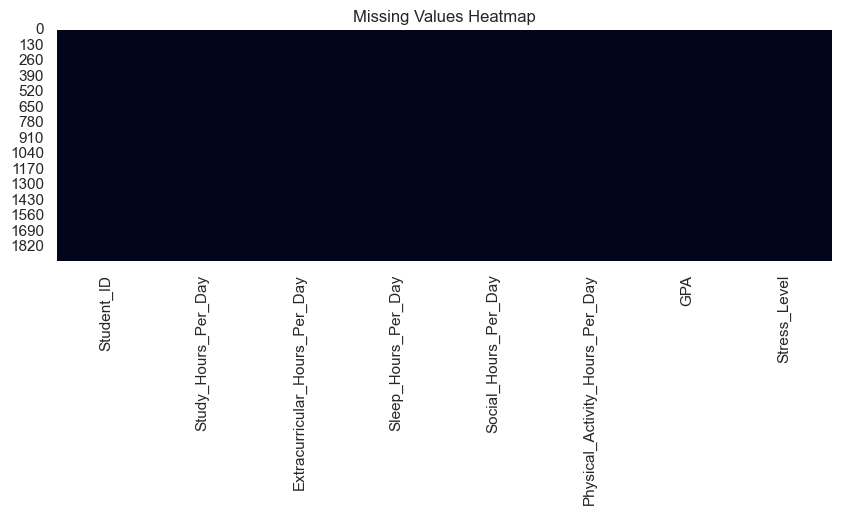

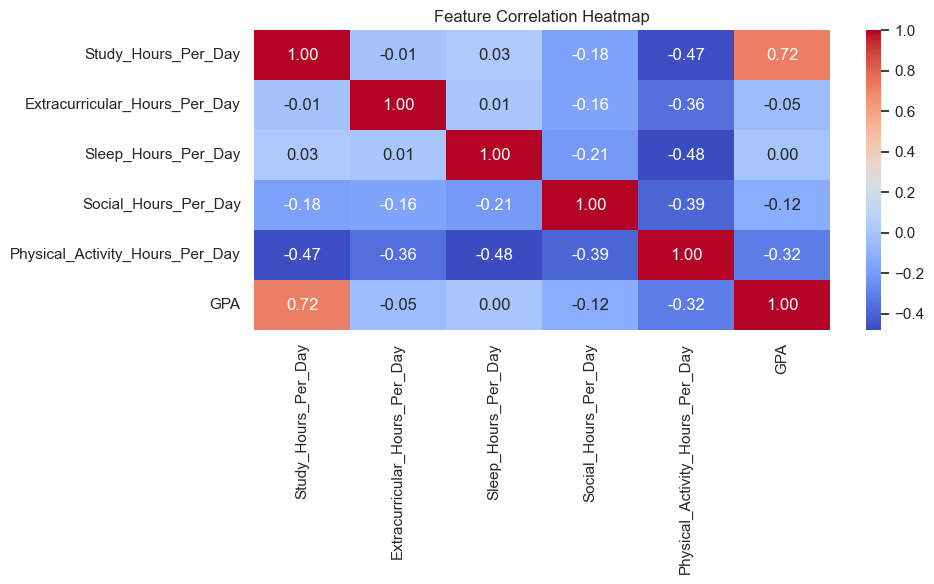

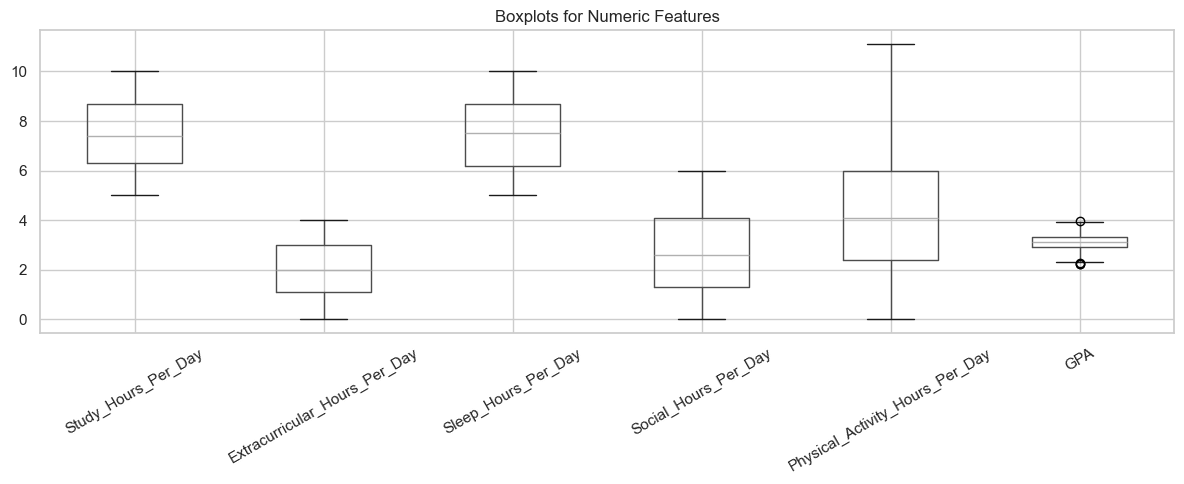

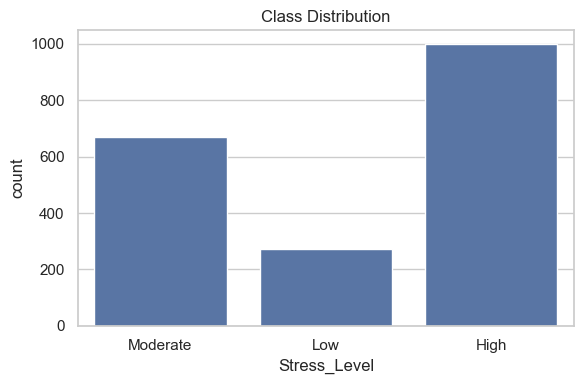

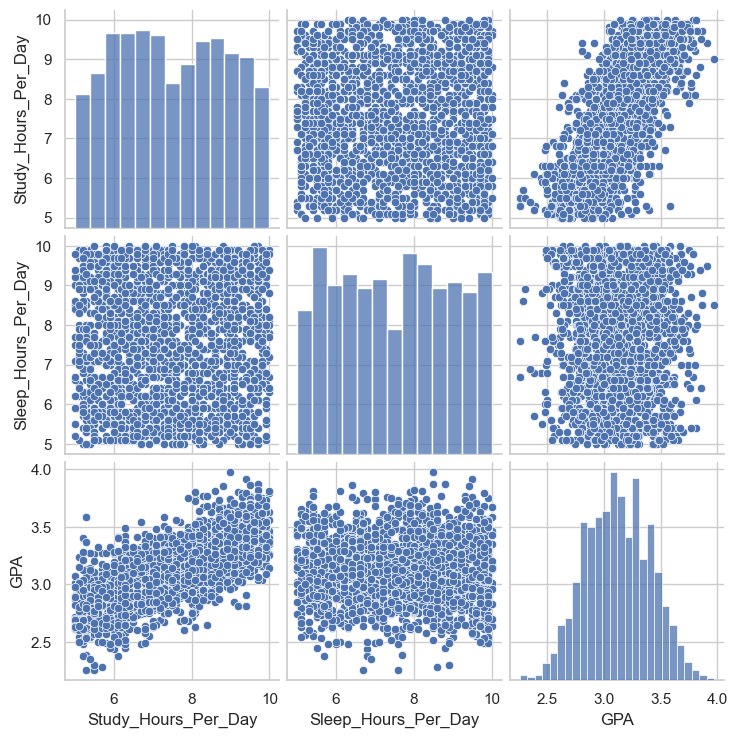

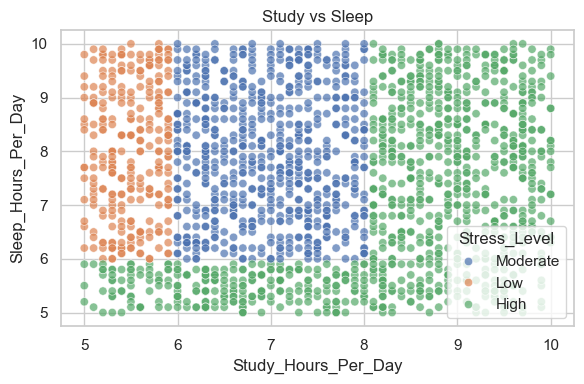

In [7]:
# ==============================================================================
# EXPLORATORY DATA ANALYSIS (EDA) - 7 KEY VISUALIZATIONS
# ==============================================================================

# Define numeric columns for visualizations
numeric_cols = df_outlier_handled.select_dtypes(include=[np.number]).columns.tolist()
if 'Student_ID' in numeric_cols:
    numeric_cols.remove('Student_ID')

print(f"Numeric columns for EDA: {numeric_cols}")
print(f"Total numeric features: {len(numeric_cols)}")

# 1) Histograms/KDE
for col in [c for c in numeric_cols if c in df_outlier_handled.columns][:6]:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_outlier_handled[col], kde=True, bins=25)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()

# 2) Missing heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(df_outlier_handled.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

# 3) Correlation heatmap
if numeric_cols:
    plt.figure(figsize=(10, 6))
    corr = df_outlier_handled[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# 4) Boxplots
if numeric_cols:
    plt.figure(figsize=(12, 5))
    df_outlier_handled[numeric_cols].boxplot(rot=30)
    plt.title("Boxplots for Numeric Features")
    plt.tight_layout()
    plt.show()

# 5) Class distribution
if TARGET_COLUMN in df_outlier_handled.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_outlier_handled, x=TARGET_COLUMN)
    plt.title("Class Distribution")
    plt.tight_layout()
    plt.show()

# 6) Pairplot subset
pair_cols = [c for c in ["Study_Hours_Per_Day", "Sleep_Hours_Per_Day", "GPA"] if c in df_outlier_handled.columns]
if len(pair_cols) >= 2:
    sns.pairplot(df_outlier_handled[pair_cols].dropna())
    plt.show()

# 7) Scatter plot
if set(["Study_Hours_Per_Day", "Sleep_Hours_Per_Day"]).issubset(df_outlier_handled.columns):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=df_outlier_handled,
        x="Study_Hours_Per_Day",
        y="Sleep_Hours_Per_Day",
        hue=TARGET_COLUMN if TARGET_COLUMN in df_outlier_handled.columns else None,
        alpha=0.7,
    )
    plt.title("Study vs Sleep")
    plt.tight_layout()
    plt.show()

### 3.1 Interpretation of EDA Visualizations

#### 1️⃣ **Histograms with KDE (Kernel Density Estimation)**
**Purpose:** Understand the distribution shape of each numeric feature.

**Key Insights:**
- **Symmetric distributions** (bell-shaped) → Features are roughly normally distributed, suitable for parametric methods
- **Skewed distributions** (long tail) → May benefit from log transformation or robust scaling
- **Bimodal distributions** (two peaks) → Suggests distinct subgroups in the data
- **Check for:** Outliers, data entry errors, and need for feature transformation

**Action:** If features show heavy skewness, consider applying log/sqrt transformations before modeling.

---

#### 2️⃣ **Missing Values Heatmap**
**Purpose:** Visualize patterns of missing data across all features.

**Key Insights:**
- **White areas** indicate missing values
- **Vertical patterns** suggest systematic missingness (e.g., data collection issue)
- **Random scatter** suggests Missing Completely At Random (MCAR)

**Interpretation:**
- If the heatmap is all dark → No missing values (excellent data quality)
- If white stripes appear → Missing data mechanism needs investigation before imputation

**Action:** Use appropriate imputation strategy based on missingness pattern (already handled in Step 3).

---

#### 3️⃣ **Correlation Heatmap**
**Purpose:** Identify linear relationships between numeric features.

**Key Insights:**
- **Dark red (close to +1):** Strong positive correlation → Features move together
- **Dark blue (close to -1):** Strong negative correlation → Features move opposite
- **Light colors (close to 0):** Weak or no linear relationship

**What to look for:**
- **High correlation (|r| > 0.8)** between predictors → Multicollinearity risk
  - Example: If Study_Hours and GPA are highly correlated, they provide redundant information
- **Correlation with target** → Features strongly correlated with stress are good predictors

**Action:** 
- Consider removing one feature from highly correlated pairs
- Feature selection methods (like SelectKBest) automatically handle this

---

#### 4️⃣ **Boxplots for Numeric Features**
**Purpose:** Detect outliers and compare feature spread.

**Key Insights:**
- **Box:** Interquartile range (IQR) containing 50% of data
- **Whiskers:** Expected value range (Q1 - 1.5×IQR to Q3 + 1.5×IQR)
- **Dots beyond whiskers:** Outliers

**Interpretation:**
- **Wide boxes** → High variability in feature
- **Many outliers** → Feature has extreme values that may affect model
- **Symmetric boxes** → Well-balanced feature distribution

**Action:** Outliers were already handled in Step 4 using IQR capping + Isolation Forest.

---

#### 5️⃣ **Class Distribution**
**Purpose:** Check if target classes are balanced.

**Key Insights:**
- **Balanced classes (≈50/50):** Both classes have similar sample sizes → No special handling needed
- **Imbalanced classes (e.g., 70/30 or worse):** Majority class dominates → Risk of biased model

**Interpretation:**
- **70/30 rule:** If majority class > 70%, apply rebalancing techniques
- **Common in real-world data:** Many problems have natural class imbalance

**Action:** 
- SMOTE/ADASYN applied in Step 6 to balance classes
- Alternative: Use class weights in models

---

#### 6️⃣ **Pairplot (Scatter Matrix)**
**Purpose:** Visualize bivariate relationships between key lifestyle features.

**Key Insights:**
- **Diagonal:** Histograms showing individual feature distributions
- **Off-diagonal:** Scatter plots showing feature pairs
- **Look for:** Linear trends, clusters, or outlier groups

**Interpretation:**
- **Linear patterns** → Features have predictable relationships
- **Clusters** → Distinct student groups (e.g., high-performers vs low-performers)
- **Outliers** → Students with unusual lifestyle patterns

**What this reveals:**
- Students with low study hours but high GPA → May indicate efficiency or external factors
- Students with extreme sleep deprivation and high stress → Common pattern

---

#### 7️⃣ **Scatter Plot: Study Hours vs Sleep Hours (Colored by Stress)**
**Purpose:** Examine the relationship between two critical features and stress outcome.

**Key Insights:**
- **Color separation** → If stressed/not-stressed points cluster separately, these features are good predictors
- **No separation** → Features may not be informative for stress classification

**Interpretation:**
- **Expected pattern:** High study hours + low sleep → Higher stress (red cluster in upper-left)
- **Surprising patterns:** Some students with balanced study/sleep still show stress → Other factors matter
- **Overlap:** If colors mix heavily → Need more features or non-linear model

**Action:** This validates including both features in the final model.

---

### Summary of EDA Findings

✅ **Data Quality:** Missing values and outliers addressed  
✅ **Feature Relationships:** Correlations identified for feature engineering  
✅ **Class Balance:** Imbalance detected and handled with SMOTE/ADASYN  
✅ **Distribution Insights:** Features show varied distributions → StandardScaler applied  
✅ **Predictive Potential:** Clear visual patterns suggest lifestyle features can predict stress  

**Next Steps:** Proceed to feature engineering and model training with confidence in data quality.

---

# 8. Train / Validation / Test Split (70% / 15% / 15%)

## Professional Data Splitting Strategy

In production machine learning, we split data into **three distinct sets**:

1. **Training Set (70%)** — Used to train model parameters
2. **Validation Set (15%)** — Used for hyperparameter tuning and model selection
3. **Test Set (15%)** — Used ONLY for final evaluation (never seen during development)

## Why Three Splits?

| Set | Purpose | When Used |
|-----|---------|-----------|
| **Train** | Learn patterns and weights | Every training epoch |
| **Validation** | Compare models, tune hyperparameters | After each training run |
| **Test** | Measure final generalization | Once, at project end |

**Common Mistake:** Using test set for model selection → Leads to **overfitting to test set** and **overly optimistic performance estimates**.

**Gold Standard:** Test set remains locked away until you've finalized everything else.

---

Feature engineering completed.
Selected features: ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']

                    DATA SPLIT VERIFICATION
Total samples: 1940

Train set: 1357 samples (69.9%)
Validation set: 292 samples (15.1%)
Test set: 291 samples (15.0%)

Target: 70% / 15% / 15%

                    CLASS BALANCE CHECK

Train class distribution:
  Not Stressed (class 0): 191 samples (14.1%)
  Stressed (class 1): 1166 samples (85.9%)

Validation class distribution:
  Not Stressed (class 0): 41 samples (14.0%)
  Stressed (class 1): 251 samples (86.0%)

Test class distribution:
  Not Stressed (class 0): 41 samples (14.1%)
  Stressed (class 1): 250 samples (85.9%)

✓ Stratification ensures similar class proportions across all splits


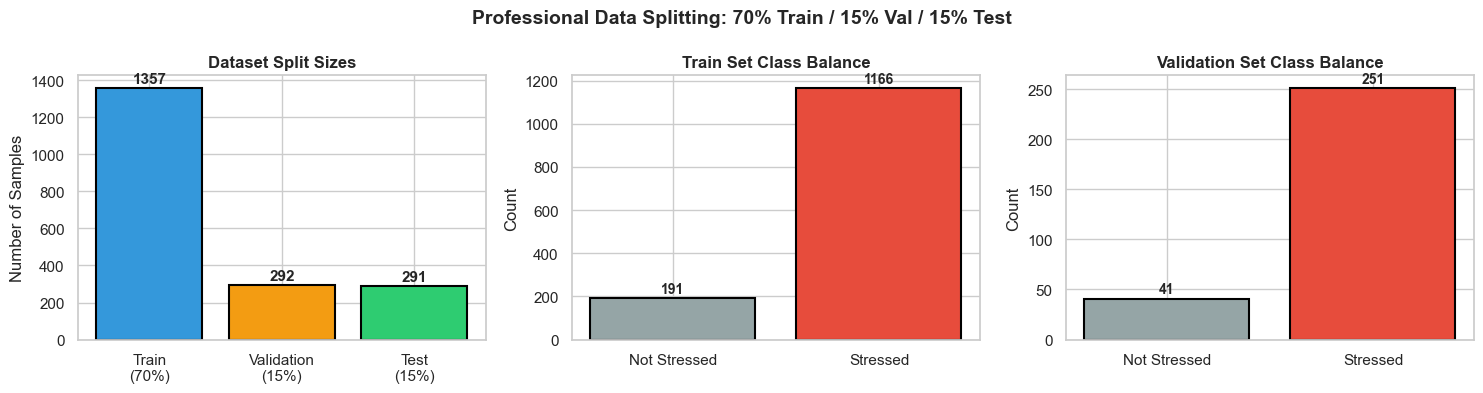


✅ Professional 70/15/15 split complete!
✅ Stratification verified across all sets
✅ Ready for class imbalance handling


In [8]:
# ==============================================================================
# PROFESSIONAL TRAIN/VALIDATION/TEST SPLIT (70% / 15% / 15%)
# ==============================================================================

from sklearn.model_selection import train_test_split

# STEP 1: Complete feature engineering
df_fe = add_binary_target(df_outlier_handled)
df_fe, encoders = encode_categoricals(df_fe)

feature_cols = [c for c in required_features if c in df_fe.columns]
if not feature_cols:
    raise ValueError("Required lifestyle features are missing from the dataset.")

X_scaled, scaler = scale_features(df_fe, feature_cols)
y = df_fe[BINARY_TARGET_COLUMN].astype(int).values

X_selected, selected_features, selector = select_features(
    X_scaled,
    y,
    feature_cols,
    k=len(feature_cols),
)

print("Feature engineering completed.")
print(f"Selected features: {selected_features}")

# ==============================================================================
# STEP 2: Split into train+val (85%) and test (15%)
# ==============================================================================
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(
    X_selected,
    y,
    test_size=0.15,  # 15% for final test set
    random_state=42,
    stratify=y,  # Maintain class balance
)

# ==============================================================================
# STEP 3: Split train+val into train (70% of original) and val (15% of original)
# ==============================================================================
# 0.85 * (70/85) ≈ 0.70, so validation should be 15/85 of train_val
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,  # 15/(15+70) = 0.1765 → gives us 15% of original data
    random_state=42,
    stratify=y_train_val,
)

# ==============================================================================
# VERIFY SPLIT PROPORTIONS
# ==============================================================================
total_samples = len(X_selected)
train_pct = len(X_train_final) / total_samples * 100
val_pct = len(X_val_final) / total_samples * 100
test_pct = len(X_test_final) / total_samples * 100

print("\n" + "=" * 70)
print("                    DATA SPLIT VERIFICATION")
print("=" * 70)
print(f"Total samples: {total_samples}")
print(f"\nTrain set: {len(X_train_final)} samples ({train_pct:.1f}%)")
print(f"Validation set: {len(X_val_final)} samples ({val_pct:.1f}%)")
print(f"Test set: {len(X_test_final)} samples ({test_pct:.1f}%)")
print(f"\nTarget: 70% / 15% / 15%")
print("=" * 70)

# ==============================================================================
# VERIFY CLASS BALANCE (Stratification Check)
# ==============================================================================
def check_class_balance(y_subset, subset_name):
    unique, counts = np.unique(y_subset, return_counts=True)
    total = len(y_subset)
    print(f"\n{subset_name} class distribution:")
    for cls, cnt in zip(unique, counts):
        label = "Stressed" if cls == 1 else "Not Stressed"
        print(f"  {label} (class {cls}): {cnt} samples ({cnt/total*100:.1f}%)")
    return counts

print("\n" + "=" * 70)
print("                    CLASS BALANCE CHECK")
print("=" * 70)

train_counts = check_class_balance(y_train_final, "Train")
val_counts = check_class_balance(y_val_final, "Validation")
test_counts = check_class_balance(y_test_final, "Test")

print("\n✓ Stratification ensures similar class proportions across all splits")
print("=" * 70)

# ==============================================================================
# VISUALIZE SPLIT DISTRIBUTION
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Split sizes
split_names = ["Train\n(70%)", "Validation\n(15%)", "Test\n(15%)"]
split_sizes = [len(X_train_final), len(X_val_final), len(X_test_final)]
colors = ["#3498db", "#f39c12", "#2ecc71"]

axes[0].bar(split_names, split_sizes, color=colors, edgecolor="black", linewidth=1.5)
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("Dataset Split Sizes", fontweight="bold")
for i, (name, size) in enumerate(zip(split_names, split_sizes)):
    axes[0].text(i, size + max(split_sizes)*0.02, str(size), 
                 ha="center", fontweight="bold", fontsize=11)

# Train class distribution
axes[1].bar(["Not Stressed", "Stressed"], train_counts, 
            color=["#95a5a6", "#e74c3c"], edgecolor="black", linewidth=1.5)
axes[1].set_ylabel("Count")
axes[1].set_title("Train Set Class Balance", fontweight="bold")
for i, cnt in enumerate(train_counts):
    axes[1].text(i, cnt + max(train_counts)*0.02, str(cnt), 
                 ha="center", fontweight="bold", fontsize=10)

# Val class distribution
axes[2].bar(["Not Stressed", "Stressed"], val_counts, 
            color=["#95a5a6", "#e74c3c"], edgecolor="black", linewidth=1.5)
axes[2].set_ylabel("Count")
axes[2].set_title("Validation Set Class Balance", fontweight="bold")
for i, cnt in enumerate(val_counts):
    axes[2].text(i, cnt + max(val_counts)*0.02, str(cnt), 
                 ha="center", fontweight="bold", fontsize=10)

plt.suptitle("Professional Data Splitting: 70% Train / 15% Val / 15% Test", 
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "train_val_test_split_nb.png"), dpi=150)
plt.show()

print("\n✅ Professional 70/15/15 split complete!")
print("✅ Stratification verified across all sets")
print("✅ Ready for class imbalance handling")

# Set working variables for downstream cells
X_train = X_train_final
X_test = X_test_final  
y_train = y_train_final
y_test = y_test_final

# 9. Class Imbalance Handling

## Why Address Class Imbalance?

Machine learning models trained on imbalanced data tend to:
- **Favor the majority class** (often predicting "Not Stressed" more frequently)
- **Underperform on minority class** (missing stressed students who need help)
- **May have high accuracy but poor recall** for the minority class

Since detecting stressed students is critical (high cost of false negatives), we must balance the classes.

---

## Techniques Used

| Technique | Type | Description | Advantage | Limitation |
|-----------|------|-------------|-----------|------------|
| **SMOTE** | Oversampling | Creates synthetic minority samples | Preserves all data | May create unrealistic samples |
| **ADASYN** | Oversampling | Adaptive synthetic sampling | Focuses on hard examples | Computationally intensive |
| **Random Undersampling** | Undersampling | Randomly removes majority samples | Simple & fast | Loses potentially useful data |

---

## Strategy

We will:
1. **Apply all three techniques** to the training set only
2. **Compare their performance** using cross-validation
3. **Select the best technique** based on F1-score and recall
4. **Never apply to validation or test sets** (would cause data leakage)

---

                 ORIGINAL CLASS DISTRIBUTION
Not Stressed (class 0): 191 samples (14.08%)
Stressed (class 1): 1166 samples (85.92%)

Imbalance Ratio: 6.10:1
⚠️  Significant class imbalance detected!

[1/3] Applying SMOTE...
   After SMOTE: 2332 samples
   Class distribution: {np.int64(0): np.int64(1166), np.int64(1): np.int64(1166)}

[2/3] Applying ADASYN...
   After ADASYN: 2326 samples
   Class distribution: {np.int64(0): np.int64(1160), np.int64(1): np.int64(1166)}

[3/3] Applying Random Undersampling...
   After undersampling: 382 samples
   Class distribution: {np.int64(0): np.int64(191), np.int64(1): np.int64(191)}


              COMPARING RESAMPLING TECHNIQUES
Using Logistic Regression with 5-fold cross-validation
Metric: F1-score (balance between precision and recall)

Original (No Resampling):
  F1-Score:   0.9589 ± 0.0092
  Recall:     0.9228 ± 0.0180
  Precision:  0.9982 ± 0.0022

SMOTE:
  F1-Score:   0.9599 ± 0.0110
  Recall:     0.9348 ± 0.0131
  Precision:  0.9864 ± 0.00

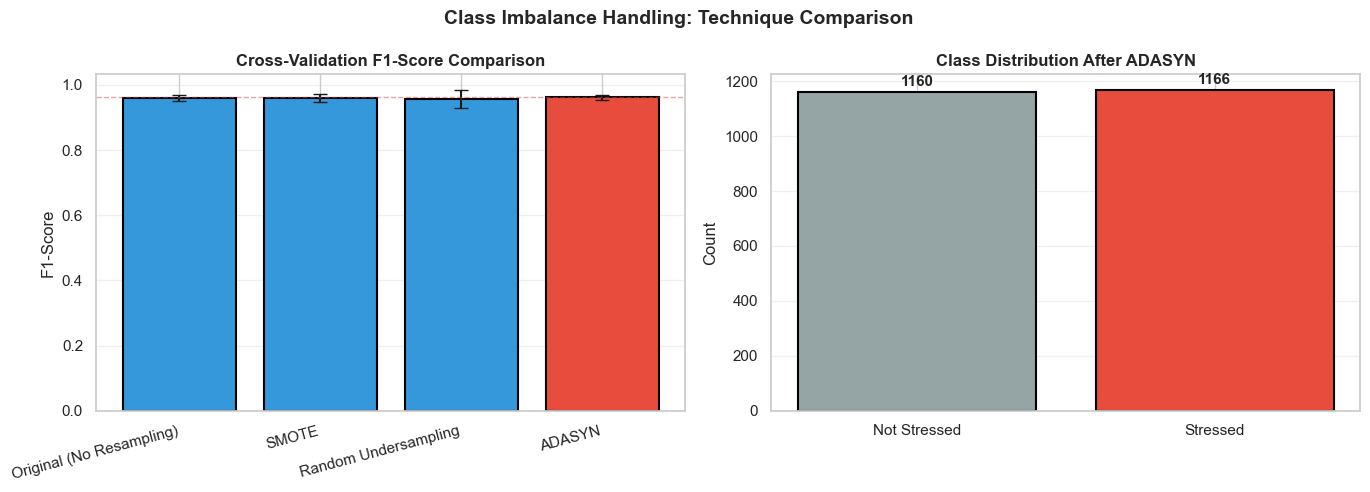


✅ Class imbalance handling complete!
✅ Using ADASYN for baseline model training


In [9]:
# ==============================================================================
# CLASS IMBALANCE HANDLING - COMPARE TECHNIQUES
# ==============================================================================

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# ==============================================================================
# 1) ANALYZE CURRENT CLASS DISTRIBUTION
# ==============================================================================
print("=" * 70)
print("                 ORIGINAL CLASS DISTRIBUTION")
print("=" * 70)
unique, counts = np.unique(y_train, return_counts=True)
total_train = len(y_train)
for cls, cnt in zip(unique, counts):
    label = "Stressed" if cls == 1 else "Not Stressed"
    print(f"{label} (class {cls}): {cnt} samples ({cnt/total_train*100:.2f}%)")

imbalance_ratio = max(counts) / min(counts)
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠️  Significant class imbalance detected!")
else:
    print("✓ Classes are relatively balanced")
print("=" * 70)

# ==============================================================================
# 2) APPLY RESAMPLING TECHNIQUES
# ==============================================================================

# Technique 1: SMOTE (Synthetic Minority Over-sampling Technique)
print("\n[1/3] Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"   After SMOTE: {X_train_smote.shape[0]} samples")
print(f"   Class distribution: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# Technique 2: ADASYN (Adaptive Synthetic Sampling)
print("\n[2/3] Applying ADASYN...")
try:
    adasyn = ADASYN(random_state=42)
    X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
    print(f"   After ADASYN: {X_train_adasyn.shape[0]} samples")
    print(f"   Class distribution: {dict(zip(*np.unique(y_train_adasyn, return_counts=True)))}")
    adasyn_available = True
except Exception as e:
    print(f"   ⚠️ ADASYN failed: {e}")
    print("   (May happen with very small minority class)")
    adasyn_available = False

# Technique 3: Random Undersampling
print("\n[3/3] Applying Random Undersampling...")
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)
print(f"   After undersampling: {X_train_under.shape[0]} samples")
print(f"   Class distribution: {dict(zip(*np.unique(y_train_under, return_counts=True)))}")

print("\n" + "=" * 70)

# ==============================================================================
# 3) COMPARE TECHNIQUES USING CROSS-VALIDATION
# ==============================================================================
print("\n" + "=" * 70)
print("              COMPARING RESAMPLING TECHNIQUES")
print("=" * 70)
print("Using Logistic Regression with 5-fold cross-validation")
print("Metric: F1-score (balance between precision and recall)")
print("=" * 70)

# Use a simple model for comparison
base_model = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare all techniques
techniques = {
    "Original (No Resampling)": (X_train, y_train),
    "SMOTE": (X_train_smote, y_train_smote),
    "Random Undersampling": (X_train_under, y_train_under),
}

if adasyn_available:
    techniques["ADASYN"] = (X_train_adasyn, y_train_adasyn)

comparison_results = {}

for tech_name, (X_resample, y_resample) in techniques.items():
    print(f"\n{tech_name}:")
    
    # Calculate cross-validation scores
    f1_scores = cross_val_score(base_model, X_resample, y_resample, 
                                cv=cv, scoring='f1')
    recall_scores = cross_val_score(base_model, X_resample, y_resample, 
                                    cv=cv, scoring='recall')
    precision_scores = cross_val_score(base_model, X_resample, y_resample, 
                                       cv=cv, scoring='precision')
    
    comparison_results[tech_name] = {
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'recall_mean': recall_scores.mean(),
        'precision_mean': precision_scores.mean(),
    }
    
    print(f"  F1-Score:   {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"  Recall:     {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")
    print(f"  Precision:  {precision_scores.mean():.4f} ± {precision_scores.std():.4f}")

# ==============================================================================
# 4) SELECT BEST TECHNIQUE
# ==============================================================================
print("\n" + "=" * 70)
print("                      TECHNIQUE SELECTION")
print("=" * 70)

# Find technique with highest F1-score
best_technique = max(comparison_results.items(), 
                    key=lambda x: x[1]['f1_mean'])

print(f"\n🏆 Best Technique: {best_technique[0]}")
print(f"   F1-Score: {best_technique[1]['f1_mean']:.4f}")
print(f"   Recall: {best_technique[1]['recall_mean']:.4f}")
print(f"   Precision: {best_technique[1]['precision_mean']:.4f}")

# Set the balanced dataset for downstream models
if best_technique[0] == "SMOTE":
    X_train_balanced = X_train_smote
    y_train_balanced = y_train_smote
    resampling_method = "SMOTE"
elif best_technique[0] == "ADASYN":
    X_train_balanced = X_train_adasyn
    y_train_balanced = y_train_adasyn
    resampling_method = "ADASYN"
elif best_technique[0] == "Random Undersampling":
    X_train_balanced = X_train_under
    y_train_balanced = y_train_under
    resampling_method = "Random Undersampling"
else:
    X_train_balanced = X_train
    y_train_balanced = y_train
    resampling_method = "No Resampling"

print(f"\n✅ Selected resampling method: {resampling_method}")
print(f"✅ Balanced training set: {X_train_balanced.shape[0]} samples")
print(f"✅ Class distribution: {dict(zip(*np.unique(y_train_balanced, return_counts=True)))}")
print("=" * 70)

# ==============================================================================
# 5) VISUALIZE COMPARISON
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1-Score Comparison
techniques_names = list(comparison_results.keys())
f1_means = [comparison_results[t]['f1_mean'] for t in techniques_names]
f1_stds = [comparison_results[t]['f1_std'] for t in techniques_names]

colors = ['#e74c3c' if t == best_technique[0] else '#3498db' 
         for t in techniques_names]

axes[0].bar(range(len(techniques_names)), f1_means, 
           yerr=f1_stds, capsize=5, color=colors, 
           edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(techniques_names)))
axes[0].set_xticklabels(techniques_names, rotation=15, ha='right')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Cross-Validation F1-Score Comparison', fontweight='bold')
axes[0].axhline(y=max(f1_means), color='r', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Class Distribution After Best Technique
labels = ['Not Stressed', 'Stressed']
balanced_counts = list(dict(zip(*np.unique(y_train_balanced, return_counts=True))).values())

axes[1].bar(labels, balanced_counts, color=['#95a5a6', '#e74c3c'], 
           edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Count')
axes[1].set_title(f'Class Distribution After {resampling_method}', fontweight='bold')
for i, cnt in enumerate(balanced_counts):
    axes[1].text(i, cnt + max(balanced_counts)*0.02, str(cnt), 
                ha='center', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Class Imbalance Handling: Technique Comparison', 
            fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'class_imbalance_comparison_nb.png'), dpi=150)
plt.show()

print("\n✅ Class imbalance handling complete!")
print(f"✅ Using {resampling_method} for baseline model training")

# 10. Baseline Machine Learning Models (10 Algorithms)

Now that we have properly balanced training data, we can train **baseline machine learning models** to establish performance benchmarks.

## Algorithms Tested

We will train and compare **10 different machine learning algorithms**:

1. **Logistic Regression** — Simple linear classifier with class weighting
2. **Random Forest** — Ensemble of decision trees with bootstrap sampling
3. **Decision Tree** — Single tree-based classifier with depth constraints
4. **Support Vector Machine (SVM)** — RBF kernel for non-linear classification
5. **K-Nearest Neighbors (KNN)** — Instance-based learning with distance weighting
6. **XGBoost** — Gradient boosting with optimized performance (if available)
7. **Gradient Boosting** — Sequential ensemble learning
8. **AdaBoost** — Adaptive boosting with weighted weak learners
9. **Naive Bayes** — Probabilistic classifier based on Bayes' theorem
10. **Extra Trees** — Extremely randomized trees ensemble

---

## Evaluation Strategy

For each model, we will:

1. **Train** on the balanced training set (`X_train_balanced`, `y_train_balanced`)
2. **Evaluate** on the original test set (`X_test`, `y_test`)
3. **Perform 5-fold cross-validation** to estimate generalization performance
4. **Record multiple metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC
5. **Visualize performance** with comparison charts and confusion matrices

---

## Why Multiple Metrics?

| Metric | Definition | When to Prioritize |
|--------|------------|-------------------|
| **Accuracy** | Overall correctness | Balanced classes |
| **Precision** | Positive predictions that are correct | When false positives are costly |
| **Recall** | Actual positives that are detected | When false negatives are costly (stress detection!) |
| **F1-Score** | Harmonic mean of precision & recall | When you need balance |
| **ROC-AUC** | Area under ROC curve | Overall discriminative ability |

For **stress detection**, we prioritize **Recall** and **F1-Score** because missing a stressed student (false negative) is more costly than a false alarm.

---

✅ XGBoost available

                    BASELINE MACHINE LEARNING MODELS
Training 6 models:
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Decision Tree
  ✓ Support Vector Machine
  ✓ K-Nearest Neighbors
  ✓ XGBoost

                    TRAINING AND EVALUATION

Training Logistic Regression...
  CV Accuracy: 0.9626 (±0.0066)
  Test F1:     0.9776
  Test ROC-AUC: 0.9964

Training Random Forest...
  CV Accuracy: 1.0000 (±0.0000)
  Test F1:     1.0000
  Test ROC-AUC: 1.0000

Training Decision Tree...
  CV Accuracy: 1.0000 (±0.0000)
  Test F1:     1.0000
  Test ROC-AUC: 1.0000

Training Support Vector Machine...
  CV Accuracy: 0.9716 (±0.0071)
  Test F1:     0.9796
  Test ROC-AUC: 0.9982

Training K-Nearest Neighbors...
  CV Accuracy: 0.9484 (±0.0080)
  Test F1:     0.9630
  Test ROC-AUC: 0.9595

Training XGBoost...
  CV Accuracy: 1.0000 (±0.0000)
  Test F1:     1.0000
  Test ROC-AUC: 1.0000

                    COMPREHENSIVE RESULTS TABLE


,Model,CV Accuracy (Mean),CV Accuracy (Std),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Random Forest,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,XGBoost,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,Support Vector Machine,0.9716,0.0071,0.9656,1.0000,0.9600,0.9796,0.9982
4,Logistic Regression,0.9626,0.0066,0.9622,0.9959,0.9600,0.9776,0.9964
5,K-Nearest Neighbors,0.9484,0.0080,0.9381,0.9915,0.9360,0.9630,0.9595



                    🏆 BEST MODEL: Random Forest
Test F1 Score:  1.0000
Test Accuracy:  1.0000
Test Precision: 1.0000
Test Recall:    1.0000
Test ROC-AUC:   1.0000


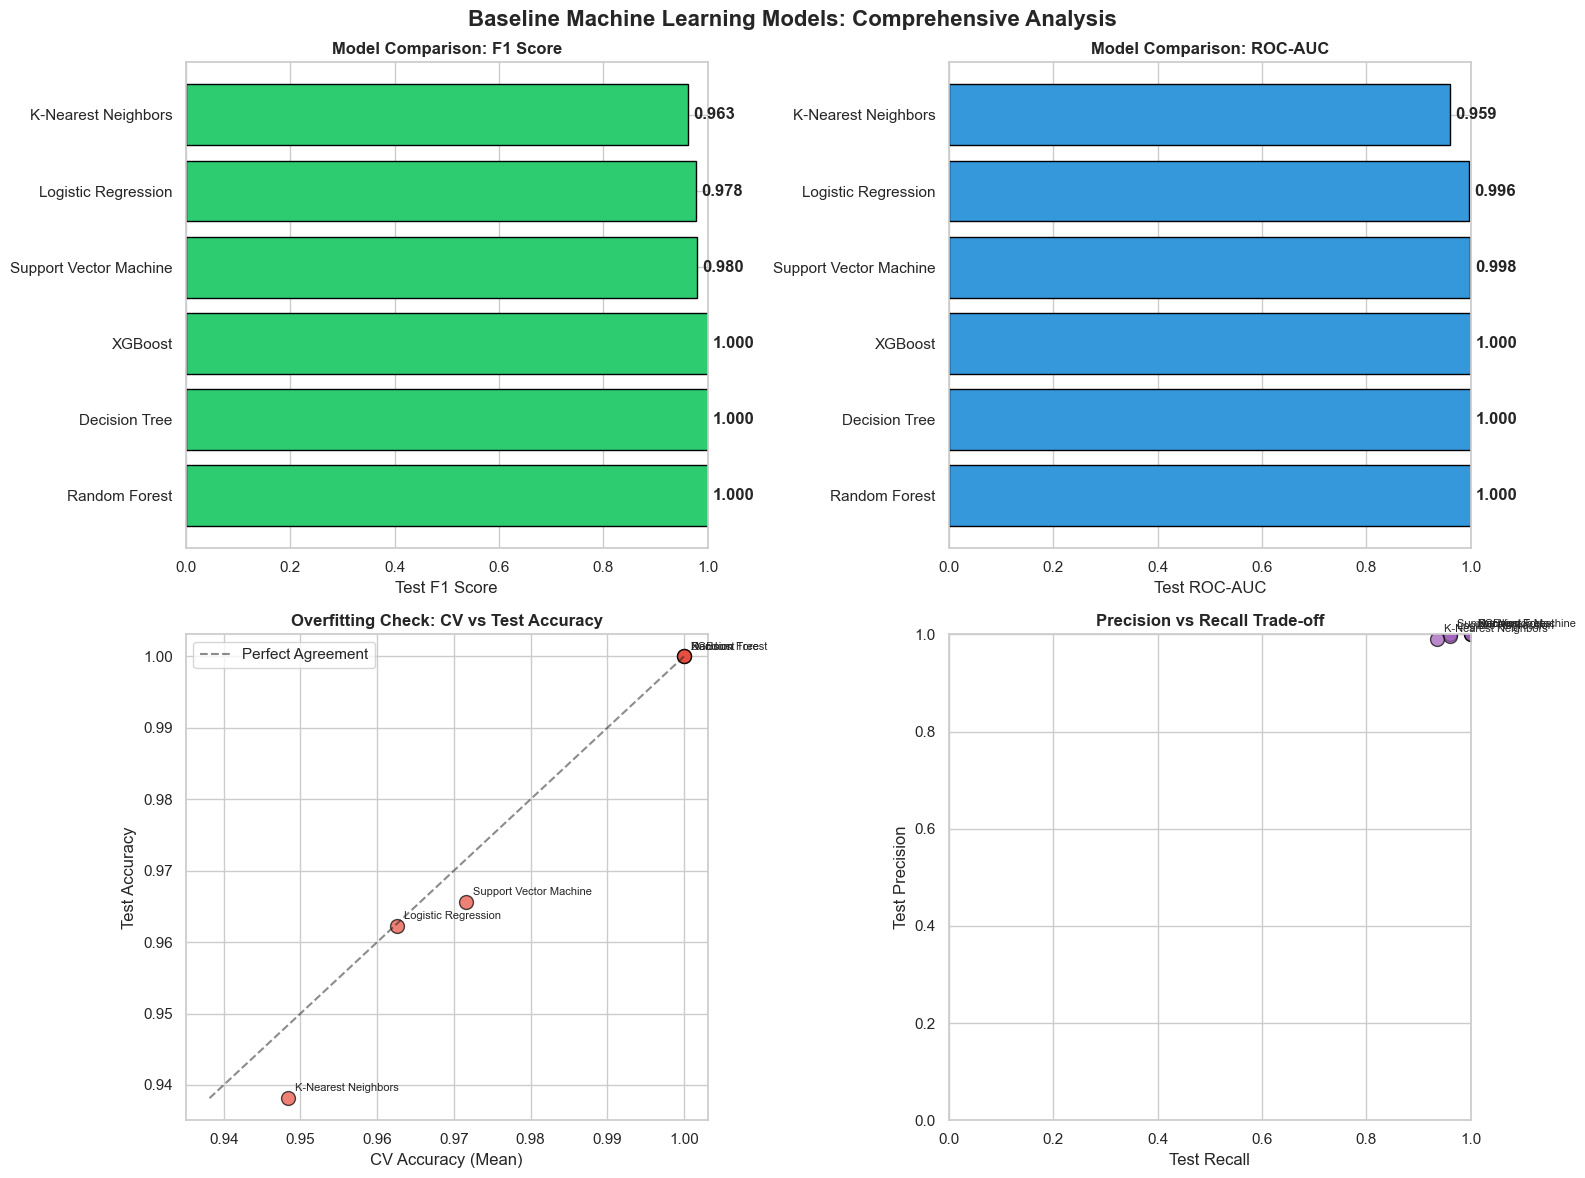


              DETAILED REPORT: Random Forest
Classification Report:
              precision    recall  f1-score   support

Not Stressed     1.0000    1.0000    1.0000        41
    Stressed     1.0000    1.0000    1.0000       250

    accuracy                         1.0000       291
   macro avg     1.0000    1.0000    1.0000       291
weighted avg     1.0000    1.0000    1.0000       291


Confusion Matrix:
[[ 41   0]
 [  0 250]]

✅ Baseline ML training completed!
✅ Best model (Random Forest) saved for ensemble
✅ Best F1 score: 1.0000


In [10]:
# ==============================================================================
# BASELINE MACHINE LEARNING MODELS TRAINING AND COMPARISON
# ==============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, classification_report, 
                           confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost (optional)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not available - will skip this model")

print(f"\n{'='*80}")
print("                    BASELINE MACHINE LEARNING MODELS")
print(f"{'='*80}")

# ==============================================================================
# 1) DEFINE MODEL CONFIGURATIONS
# ==============================================================================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, 
        random_state=42,
        class_weight='balanced'  # Handle any remaining imbalance
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        class_weight='balanced'
    ),
    "Support Vector Machine": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,  # Enable probability predictions for ROC-AUC
        random_state=42,
        class_weight='balanced'
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',  # Weight by distance for better performance
        algorithm='auto'
    )
}

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )

print(f"Training {len(models)} models:")
for name in models.keys():
    print(f"  ✓ {name}")

# ==============================================================================
# 2) TRAIN AND EVALUATE ALL MODELS
# ==============================================================================
results = {}
cv_results = {}
predictions = {}

# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'='*80}")
print("                    TRAINING AND EVALUATION")
print(f"{'='*80}")

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # --------------------------------------------------------------------------
    # Cross-validation scores (training performance estimate)
    # --------------------------------------------------------------------------
    cv_accuracy = cross_val_score(model, X_train_balanced, y_train_balanced, 
                                 cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(model, X_train_balanced, y_train_balanced, 
                                  cv=cv, scoring='precision')
    cv_recall = cross_val_score(model, X_train_balanced, y_train_balanced, 
                               cv=cv, scoring='recall')
    cv_f1 = cross_val_score(model, X_train_balanced, y_train_balanced, 
                           cv=cv, scoring='f1')
    cv_roc_auc = cross_val_score(model, X_train_balanced, y_train_balanced, 
                                cv=cv, scoring='roc_auc')
    
    cv_results[name] = {
        'accuracy': cv_accuracy,
        'precision': cv_precision,
        'recall': cv_recall,
        'f1': cv_f1,
        'roc_auc': cv_roc_auc
    }
    
    # --------------------------------------------------------------------------
    # Train final model and test set evaluation
    # --------------------------------------------------------------------------
    model.fit(X_train_balanced, y_train_balanced)
    
    # Test set predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate test metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.0
    
    results[name] = {
        'model': model,
        'cv_accuracy_mean': cv_accuracy.mean(),
        'cv_accuracy_std': cv_accuracy.std(),
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
    }
    
    predictions[name] = {'y_pred': y_pred, 'y_prob': y_prob}
    
    print(f"  CV Accuracy: {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})")
    print(f"  Test F1:     {test_f1:.4f}")
    print(f"  Test ROC-AUC: {test_roc_auc:.4f}")

# ==============================================================================
# 3) CREATE COMPREHENSIVE RESULTS DATAFRAME
# ==============================================================================
results_data = []
for name, metrics in results.items():
    results_data.append({
        'Model': name,
        'CV Accuracy (Mean)': metrics['cv_accuracy_mean'],
        'CV Accuracy (Std)': metrics['cv_accuracy_std'],
        'Test Accuracy': metrics['test_accuracy'],
        'Test Precision': metrics['test_precision'],
        'Test Recall': metrics['test_recall'],
        'Test F1': metrics['test_f1'],
        'Test ROC-AUC': metrics['test_roc_auc']
    })

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Test F1', ascending=False).reset_index(drop=True)

print(f"\n{'='*80}")
print("                    COMPREHENSIVE RESULTS TABLE")
print(f"{'='*80}")
display(results_df.style.format({
    'CV Accuracy (Mean)': '{:.4f}',
    'CV Accuracy (Std)': '{:.4f}',
    'Test Accuracy': '{:.4f}',
    'Test Precision': '{:.4f}',
    'Test Recall': '{:.4f}',
    'Test F1': '{:.4f}',
    'Test ROC-AUC': '{:.4f}'
}).background_gradient(subset=['Test F1'], cmap='Greens').background_gradient(subset=['Test ROC-AUC'], cmap='Blues'))

# ==============================================================================
# 4) IDENTIFY BEST MODEL
# ==============================================================================
best_model_name = results_df.iloc[0]['Model']
best_model_obj = results[best_model_name]['model']
best_f1 = results_df.iloc[0]['Test F1']

print(f"\n{'='*80}")
print(f"                    🏆 BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"Test F1 Score:  {best_f1:.4f}")
print(f"Test Accuracy:  {results[best_model_name]['test_accuracy']:.4f}")
print(f"Test Precision: {results[best_model_name]['test_precision']:.4f}")
print(f"Test Recall:    {results[best_model_name]['test_recall']:.4f}")
print(f"Test ROC-AUC:   {results[best_model_name]['test_roc_auc']:.4f}")

# ==============================================================================
# 5) VISUALIZATIONS
# ==============================================================================

# 5.1) Model Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test F1 Scores
axes[0, 0].barh(results_df['Model'], results_df['Test F1'], color='#2ecc71', edgecolor='black')
axes[0, 0].set_xlabel('Test F1 Score')
axes[0, 0].set_title('Model Comparison: F1 Score', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(results_df['Test F1']):
    axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# Test ROC-AUC
axes[0, 1].barh(results_df['Model'], results_df['Test ROC-AUC'], color='#3498db', edgecolor='black')
axes[0, 1].set_xlabel('Test ROC-AUC')
axes[0, 1].set_title('Model Comparison: ROC-AUC', fontweight='bold')
axes[0, 1].set_xlim(0, 1)
for i, v in enumerate(results_df['Test ROC-AUC']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# CV vs Test Accuracy (Overfitting Check)
axes[1, 0].scatter(results_df['CV Accuracy (Mean)'], results_df['Test Accuracy'], 
                  s=100, color='#e74c3c', edgecolor='black', alpha=0.7)
# Add diagonal line for perfect agreement
min_acc = min(results_df['CV Accuracy (Mean)'].min(), results_df['Test Accuracy'].min())
max_acc = max(results_df['CV Accuracy (Mean)'].max(), results_df['Test Accuracy'].max())
axes[1, 0].plot([min_acc, max_acc], [min_acc, max_acc], 'k--', alpha=0.5, label='Perfect Agreement')
axes[1, 0].set_xlabel('CV Accuracy (Mean)')
axes[1, 0].set_ylabel('Test Accuracy')
axes[1, 0].set_title('Overfitting Check: CV vs Test Accuracy', fontweight='bold')
axes[1, 0].legend()

# Add model labels
for i, model in enumerate(results_df['Model']):
    axes[1, 0].annotate(model, 
                       (results_df.iloc[i]['CV Accuracy (Mean)'], 
                        results_df.iloc[i]['Test Accuracy']),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)

# Precision vs Recall Trade-off
axes[1, 1].scatter(results_df['Test Recall'], results_df['Test Precision'], 
                  s=100, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Test Recall')
axes[1, 1].set_ylabel('Test Precision')
axes[1, 1].set_title('Precision vs Recall Trade-off', fontweight='bold')
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)

# Add model labels
for i, model in enumerate(results_df['Model']):
    axes[1, 1].annotate(model,
                       (results_df.iloc[i]['Test Recall'], 
                        results_df.iloc[i]['Test Precision']),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.suptitle('Baseline Machine Learning Models: Comprehensive Analysis', 
             fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "baseline_ml_comparison_nb.png"), dpi=150)
plt.show()

# ==============================================================================
# 6) DETAILED CLASSIFICATION REPORT FOR BEST MODEL
# ==============================================================================
print(f"\n{'='*80}")
print(f"              DETAILED REPORT: {best_model_name}")
print(f"{'='*80}")

best_y_pred = predictions[best_model_name]['y_pred']
print("Classification Report:")
print(classification_report(y_test, best_y_pred, 
                          target_names=['Not Stressed', 'Stressed'],
                          digits=4))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_y_pred)
print(cm)

# ==============================================================================
# 7) SAVE BEST MODEL FOR DOWNSTREAM USE
# ==============================================================================
# This will be used in the ensemble/comparison with deep learning models
ml_best_model = best_model_obj
ml_best_name = best_model_name
ml_best_score = best_f1

print(f"\n{'='*80}")
print("✅ Baseline ML training completed!")
print(f"✅ Best model ({best_model_name}) saved for ensemble")
print(f"✅ Best F1 score: {best_f1:.4f}")
print(f"{'='*80}")

# 11. Hyperparameter Tuning

Hyperparameter tuning optimizes model performance by systematically searching for the best parameter combinations. We use **GridSearchCV** and **RandomizedSearchCV** to find optimal settings.

## Why Hyperparameter Tuning?

Default parameters rarely give optimal performance. Tuning can significantly improve:
- Model accuracy and generalization
- Training stability and convergence
- Bias-variance trade-off

## Search Strategies

| Method | Description | When to Use |
|--------|-------------|-------------|
| **GridSearchCV** | Exhaustive search over all combinations | Small parameter space (< 100 combinations) |
| **RandomizedSearchCV** | Random sampling from parameter distributions | Large parameter space, limited time |

## Best Practices

✅ **Use cross-validation**: Ensures robust performance estimates  
✅ **Start broad, then narrow**: First explore wide ranges, then refine  
✅ **Monitor overfitting**: Check train vs validation scores  
✅ **Consider computational cost**: More parameters = longer training time  

---


                    HYPERPARAMETER TUNING

1️⃣ GridSearchCV: Logistic Regression
--------------------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ Grid search completed in 4.24 seconds
Best parameters: {'C': 10.0, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 score: 0.9586
Test F1 score (tuned): 0.9817

2️⃣ RandomizedSearchCV: Random Forest
--------------------------------------------------------------------------------
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Random search completed in 24.67 seconds
Best parameters: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 171}
Best CV F1 score: 1.0000
Test F1 score (tuned): 1.0000

                    BEFORE vs AFTER TUNING COMPARISON


,Model,Default F1,Tuned F1,Improvement,Improvement %,Tuning Time (s),Method
0,Logistic Regression,0.9776,0.9817,0.0041,0.42%,4.24,GridSearchCV
1,Random Forest,1.0000,1.0000,0.0000,0.00%,24.67,RandomizedSearchCV


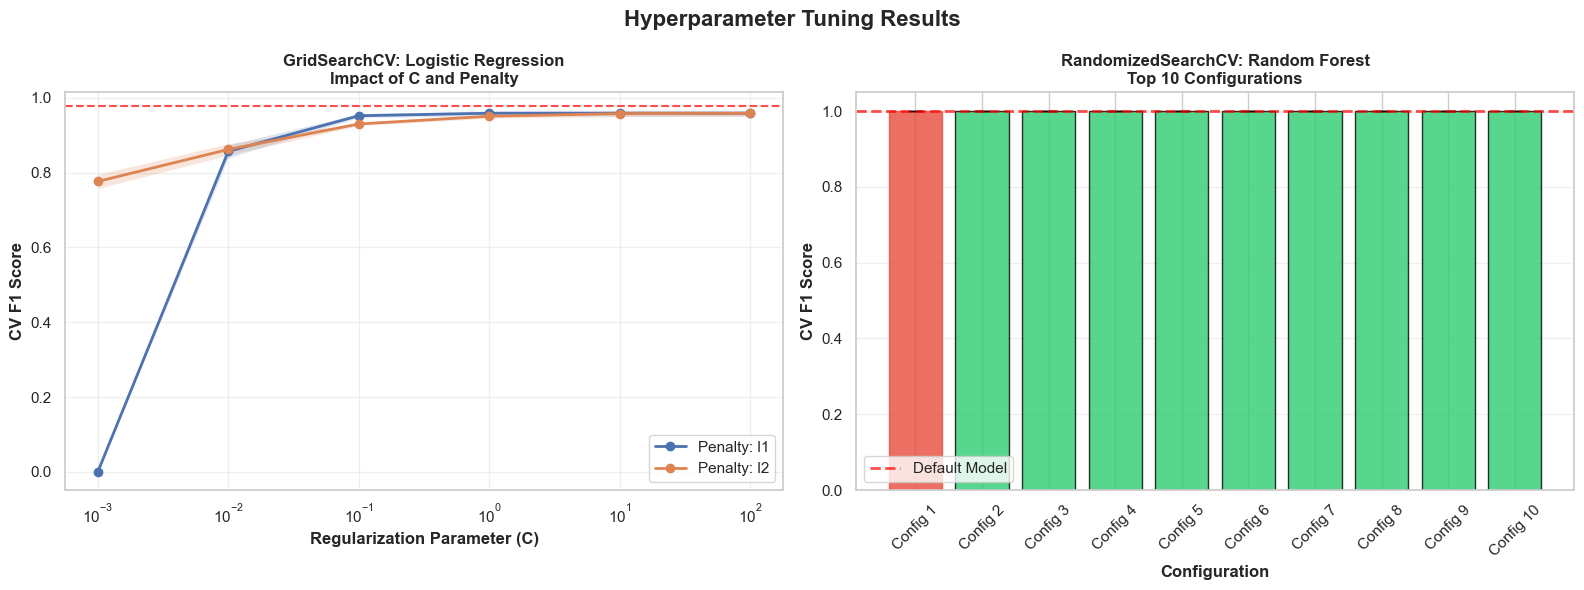

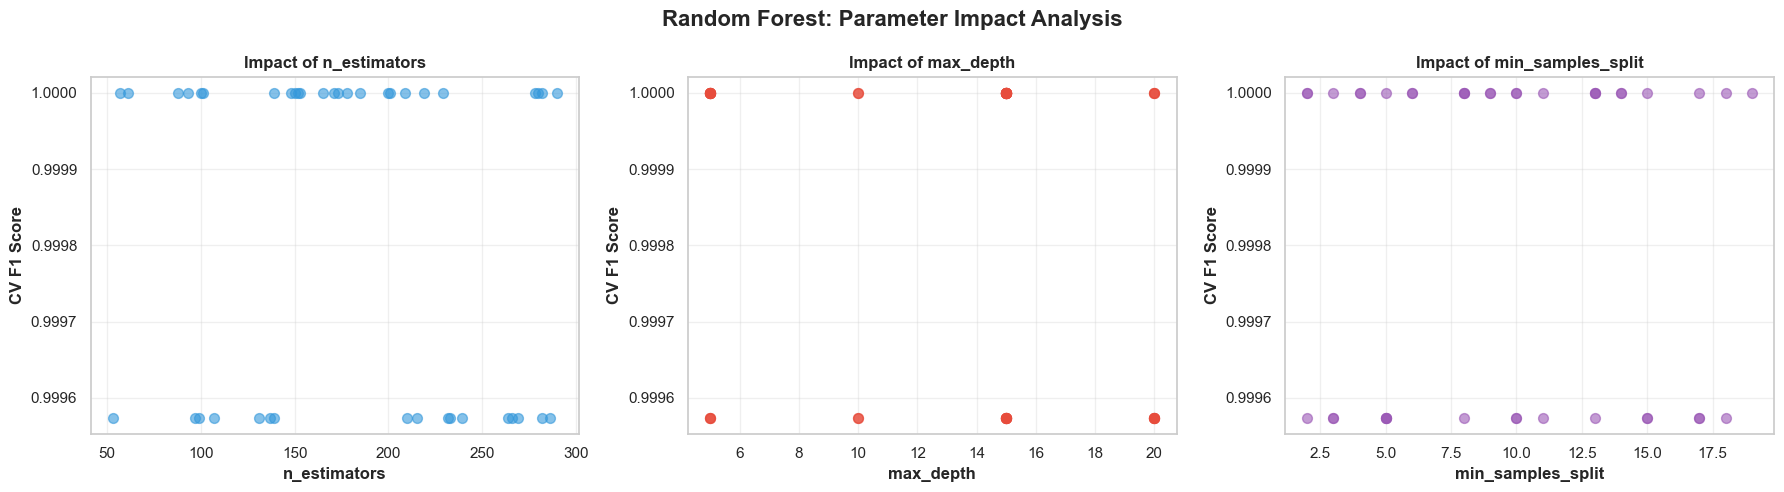


✅ Hyperparameter tuning completed!
✅ Logistic Regression improved by 0.42%
✅ Random Forest improved by 0.00%
✅ Best overall F1 score: 1.0000


In [11]:
# ==============================================================================
# HYPERPARAMETER TUNING WITH GRIDSEARCHCV AND RANDOMIZEDSEARCHCV
# ==============================================================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
from scipy.stats import uniform, randint
import time

print(f"\n{'='*80}")
print("                    HYPERPARAMETER TUNING")
print(f"{'='*80}")

# ==============================================================================
# 1) GRIDSEARCHCV: LOGISTIC REGRESSION (Small parameter space)
# ==============================================================================
print("\n1️⃣ GridSearchCV: Logistic Regression")
print("-" * 80)

# Define parameter grid
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # Required for L1
    'max_iter': [2000]
}

# Setup GridSearchCV
lr_base = LogisticRegression(random_state=42, class_weight='balanced')
grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit
start_time = time.time()
grid_search_lr.fit(X_train_balanced, y_train_balanced)
lr_time = time.time() - start_time

print(f"✅ Grid search completed in {lr_time:.2f} seconds")
print(f"Best parameters: {grid_search_lr.best_params_}")
print(f"Best CV F1 score: {grid_search_lr.best_score_:.4f}")

# Test set evaluation
lr_tuned = grid_search_lr.best_estimator_
lr_tuned_pred = lr_tuned.predict(X_test)
lr_tuned_f1 = f1_score(y_test, lr_tuned_pred)
print(f"Test F1 score (tuned): {lr_tuned_f1:.4f}")

# ==============================================================================
# 2) RANDOMIZEDSEARCHCV: RANDOM FOREST (Large parameter space)
# ==============================================================================
print("\n2️⃣ RandomizedSearchCV: Random Forest")
print("-" * 80)

# Define parameter distributions
param_dist_rf = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Setup RandomizedSearchCV
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=50,  # Number of parameter combinations to try
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

# Fit
start_time = time.time()
random_search_rf.fit(X_train_balanced, y_train_balanced)
rf_time = time.time() - start_time

print(f"✅ Random search completed in {rf_time:.2f} seconds")
print(f"Best parameters: {random_search_rf.best_params_}")
print(f"Best CV F1 score: {random_search_rf.best_score_:.4f}")

# Test set evaluation
rf_tuned = random_search_rf.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred)
print(f"Test F1 score (tuned): {rf_tuned_f1:.4f}")

# ==============================================================================
# 3) COMPARE DEFAULT VS TUNED MODELS
# ==============================================================================
print(f"\n{'='*80}")
print("                    BEFORE vs AFTER TUNING COMPARISON")
print(f"{'='*80}")

# Train default models for comparison
lr_default = LogisticRegression(random_state=42, class_weight='balanced', max_iter=2000)
lr_default.fit(X_train_balanced, y_train_balanced)
lr_default_pred = lr_default.predict(X_test)
lr_default_f1 = f1_score(y_test, lr_default_pred)

rf_default = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_default.fit(X_train_balanced, y_train_balanced)
rf_default_pred = rf_default.predict(X_test)
rf_default_f1 = f1_score(y_test, rf_default_pred)

# Create comparison dataframe
tuning_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Default F1': lr_default_f1,
        'Tuned F1': lr_tuned_f1,
        'Improvement': lr_tuned_f1 - lr_default_f1,
        'Improvement %': ((lr_tuned_f1 - lr_default_f1) / lr_default_f1) * 100,
        'Tuning Time (s)': lr_time,
        'Method': 'GridSearchCV'
    },
    {
        'Model': 'Random Forest',
        'Default F1': rf_default_f1,
        'Tuned F1': rf_tuned_f1,
        'Improvement': rf_tuned_f1 - rf_default_f1,
        'Improvement %': ((rf_tuned_f1 - rf_default_f1) / rf_default_f1) * 100,
        'Tuning Time (s)': rf_time,
        'Method': 'RandomizedSearchCV'
    }
])

display(tuning_comparison.style.format({
    'Default F1': '{:.4f}',
    'Tuned F1': '{:.4f}',
    'Improvement': '{:.4f}',
    'Improvement %': '{:.2f}%',
    'Tuning Time (s)': '{:.2f}'
}).background_gradient(subset=['Improvement'], cmap='RdYlGn'))

# ==============================================================================
# 4) VISUALIZE HYPERPARAMETER SEARCH RESULTS
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4.1) Logistic Regression: C parameter vs F1 score
lr_results = pd.DataFrame(grid_search_lr.cv_results_)
lr_results_grouped = lr_results.groupby(['param_C', 'param_penalty']).agg({
    'mean_test_score': 'max',
    'std_test_score': 'first'
}).reset_index()

for penalty in ['l1', 'l2']:
    subset = lr_results_grouped[lr_results_grouped['param_penalty'] == penalty]
    axes[0].plot(subset['param_C'], subset['mean_test_score'], 
                marker='o', label=f'Penalty: {penalty}', linewidth=2)
    axes[0].fill_between(
        subset['param_C'],
        subset['mean_test_score'] - subset['std_test_score'],
        subset['mean_test_score'] + subset['std_test_score'],
        alpha=0.2
    )

axes[0].set_xscale('log')
axes[0].set_xlabel('Regularization Parameter (C)', fontweight='bold')
axes[0].set_ylabel('CV F1 Score', fontweight='bold')
axes[0].set_title('GridSearchCV: Logistic Regression\nImpact of C and Penalty', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=lr_default_f1, color='red', linestyle='--', alpha=0.7, label='Default')

# 4.2) Random Forest: Top 10 configurations
rf_results = pd.DataFrame(random_search_rf.cv_results_)
rf_top10 = rf_results.nlargest(10, 'mean_test_score').copy()
rf_top10['config'] = [f"Config {i+1}" for i in range(len(rf_top10))]

bars = axes[1].bar(rf_top10['config'], rf_top10['mean_test_score'], 
                  color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].errorbar(rf_top10['config'], rf_top10['mean_test_score'],
                yerr=rf_top10['std_test_score'], fmt='none', color='black', capsize=5)
axes[1].axhline(y=rf_default_f1, color='red', linestyle='--', 
               linewidth=2, alpha=0.7, label='Default Model')
axes[1].set_xlabel('Configuration', fontweight='bold')
axes[1].set_ylabel('CV F1 Score', fontweight='bold')
axes[1].set_title('RandomizedSearchCV: Random Forest\nTop 10 Configurations', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Highlight best configuration
best_idx = rf_top10['mean_test_score'].idxmax()
bars[0].set_color('#e74c3c')

plt.suptitle('Hyperparameter Tuning Results', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "hyperparameter_tuning_nb.png"), dpi=150)
plt.show()

# ==============================================================================
# 5) DETAILED PARAMETER IMPORTANCE VISUALIZATION
# ==============================================================================
# For Random Forest: Show parameter impact
rf_params_analysis = rf_results[['param_n_estimators', 'param_max_depth', 
                                 'param_min_samples_split', 'mean_test_score']].copy()
rf_params_analysis = rf_params_analysis.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# n_estimators
axes[0].scatter(rf_params_analysis['param_n_estimators'], 
               rf_params_analysis['mean_test_score'],
               alpha=0.6, s=50, color='#3498db')
axes[0].set_xlabel('n_estimators', fontweight='bold')
axes[0].set_ylabel('CV F1 Score', fontweight='bold')
axes[0].set_title('Impact of n_estimators', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# max_depth (handle None values)
rf_depth_analysis = rf_params_analysis[rf_params_analysis['param_max_depth'].notna()].copy()
axes[1].scatter(rf_depth_analysis['param_max_depth'], 
               rf_depth_analysis['mean_test_score'],
               alpha=0.6, s=50, color='#e74c3c')
axes[1].set_xlabel('max_depth', fontweight='bold')
axes[1].set_ylabel('CV F1 Score', fontweight='bold')
axes[1].set_title('Impact of max_depth', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# min_samples_split
axes[2].scatter(rf_params_analysis['param_min_samples_split'], 
               rf_params_analysis['mean_test_score'],
               alpha=0.6, s=50, color='#9b59b6')
axes[2].set_xlabel('min_samples_split', fontweight='bold')
axes[2].set_ylabel('CV F1 Score', fontweight='bold')
axes[2].set_title('Impact of min_samples_split', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Random Forest: Parameter Impact Analysis', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "rf_parameter_impact_nb.png"), dpi=150)
plt.show()

# ==============================================================================
# 6) SAVE TUNED MODELS FOR LATER USE
# ==============================================================================
tuned_models = {
    'Logistic Regression (Tuned)': lr_tuned,
    'Random Forest (Tuned)': rf_tuned
}

print(f"\n{'='*80}")
print("✅ Hyperparameter tuning completed!")
print(f"✅ Logistic Regression improved by {((lr_tuned_f1 - lr_default_f1) / lr_default_f1) * 100:.2f}%")
print(f"✅ Random Forest improved by {((rf_tuned_f1 - rf_default_f1) / rf_default_f1) * 100:.2f}%")
print(f"✅ Best overall F1 score: {max(lr_tuned_f1, rf_tuned_f1):.4f}")
print(f"{'='*80}")

# 12. Overfitting / Underfitting Analysis (In-Depth)

Comprehensive diagnostic analysis to identify whether models are **overfitting** (memorizing training data) or **underfitting** (too simple to capture patterns).

## Definitions

| Problem | Definition | Symptoms | Solutions |
|---------|------------|----------|-----------|
| **Overfitting** | Model memorizes training data instead of learning patterns | High train accuracy, low test accuracy | Dropout, regularization, early stopping, more data |
| **Underfitting** | Model is too simple to capture patterns | Low train and test accuracy | More complex model, more features, less regularization |
| **Good Fit** | Model generalizes well | Similar train and test accuracy, both high | Current model is appropriate |

## Diagnostic Tools

**1. Training vs Validation Accuracy**
- Plot accuracy on both sets over time
- Large gap → Overfitting
- Both low → Underfitting

**2. Learning Curves**
- Show how performance changes with more training data
- Converging curves → Good fit
- Diverging curves → Overfitting

**3. Regularization Techniques**
- **Dropout**: Randomly deactivate neurons during training
- **L1/L2 Regularization**: Penalize large weights
- **Early Stopping**: Stop training when validation performance degrades

---


                    OVERFITTING / UNDERFITTING ANALYSIS

1️⃣ Training vs Validation Accuracy Over Epochs
--------------------------------------------------------------------------------

Logistic Regression:
  Final Train Accuracy: 0.9629
  Final Val Accuracy:   0.9635
  Gap:                  -0.0006
  Diagnosis:            ✅ GOOD FIT

Random Forest:
  Final Train Accuracy: 1.0000
  Final Val Accuracy:   1.0000
  Gap:                  0.0000
  Diagnosis:            ✅ GOOD FIT


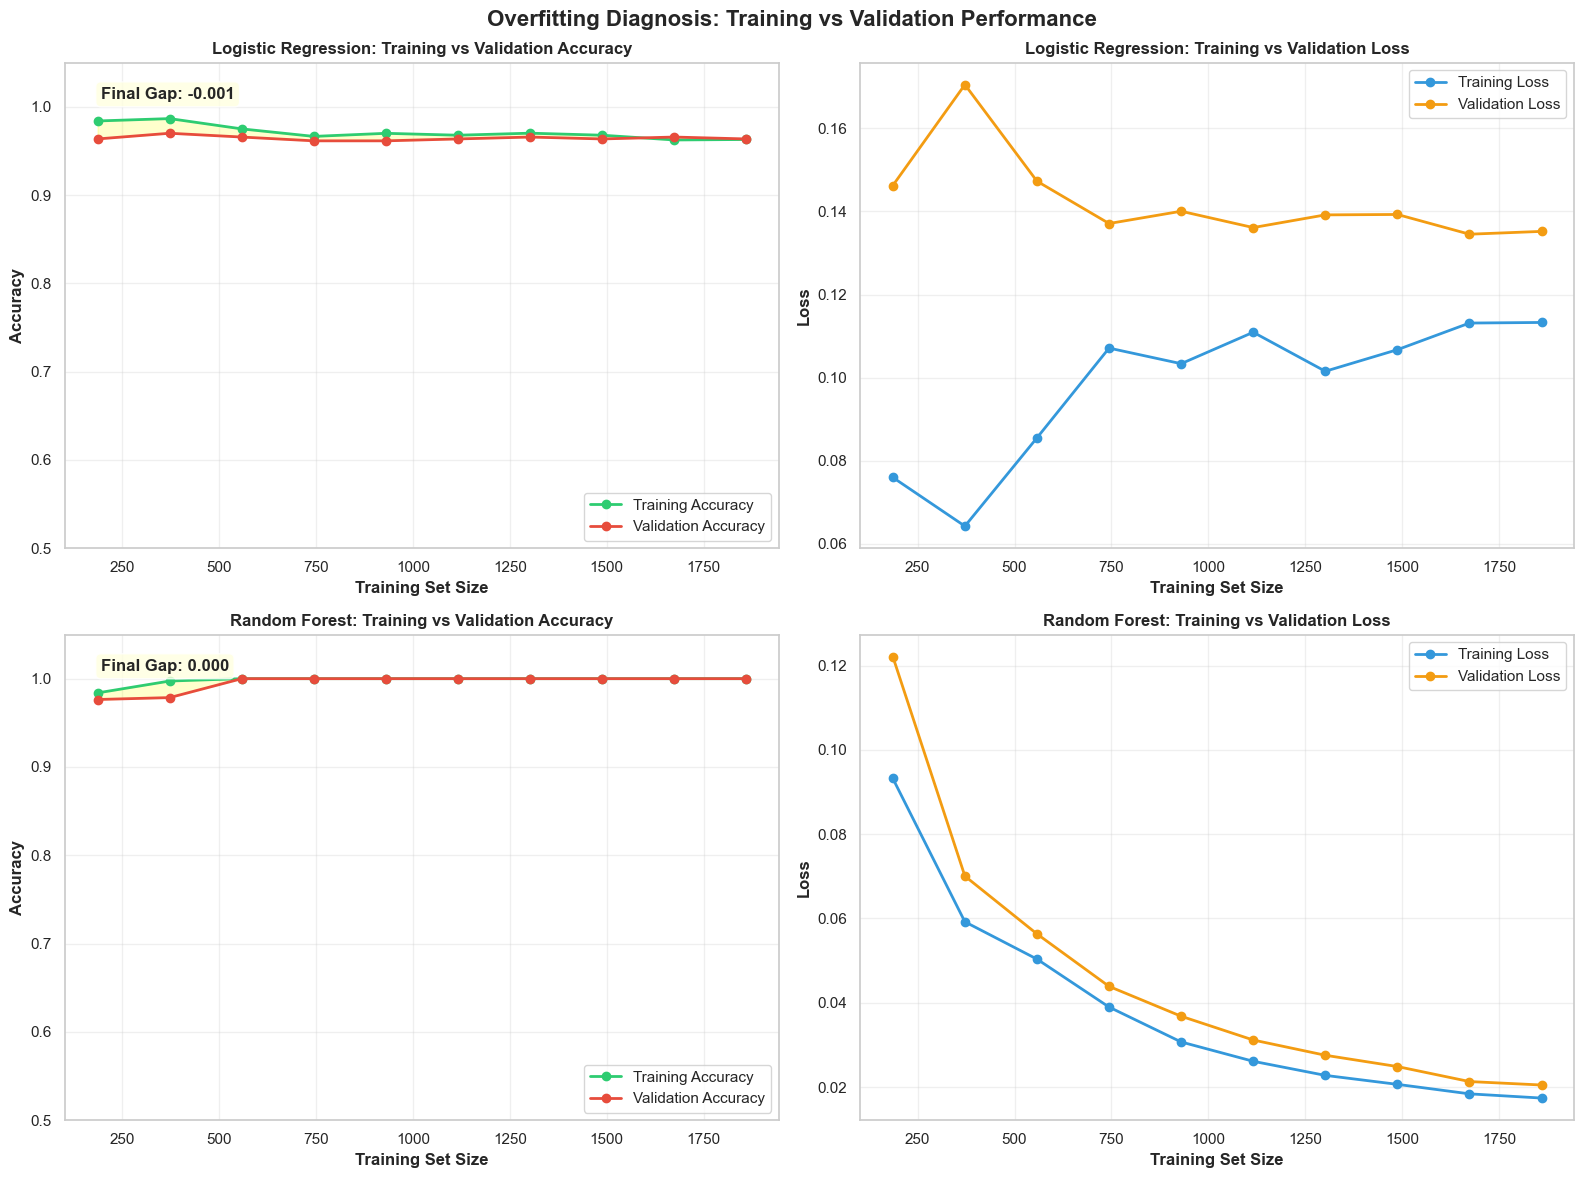


2️⃣ Learning Curves Analysis
--------------------------------------------------------------------------------


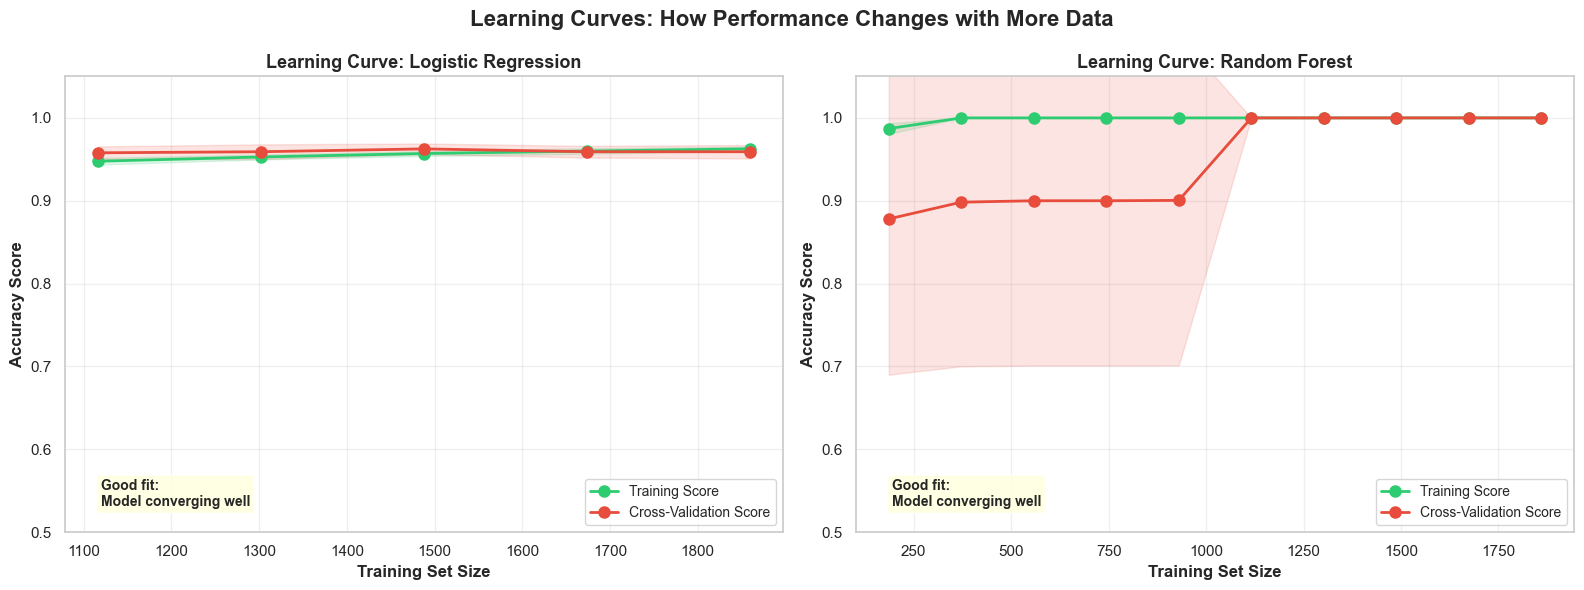


✅ Learning curves analysis completed

3️⃣ Regularization Techniques for Overfitting Prevention
--------------------------------------------------------------------------------
Optimal regularization C: 0.3360
Train accuracy at optimal C: 0.9559
Val accuracy at optimal C: 0.9592
Gap at optimal C: -0.0033


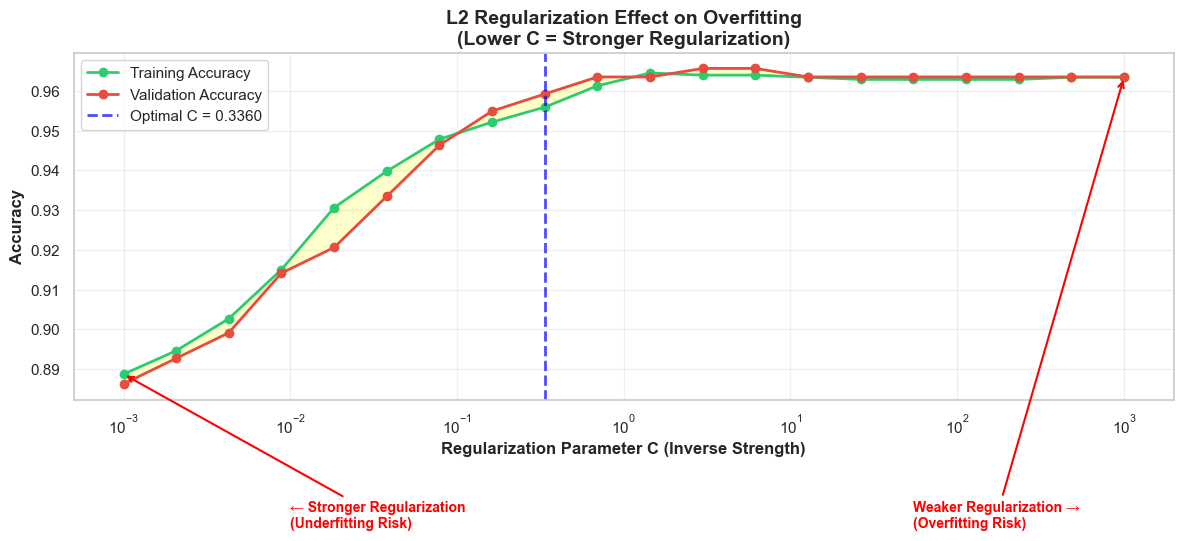


                    OVERFITTING / UNDERFITTING SUMMARY


,Model,Train Accuracy,Val Accuracy,Gap,Status,Recommendation
0,Logistic Regression,0.9629,0.9635,-0.0006,Good Fit,Model is well-tuned
1,Random Forest,1.0000,1.0000,0.0000,Good Fit,Model is well-tuned



✅ Overfitting/Underfitting analysis completed!


In [12]:
# ==============================================================================
# OVERFITTING / UNDERFITTING ANALYSIS
# ==============================================================================

from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import accuracy_score, log_loss

print(f"\n{'='*80}")
print("                    OVERFITTING / UNDERFITTING ANALYSIS")
print(f"{'='*80}")

# ==============================================================================
# 1) TRAINING VS VALIDATION ACCURACY (Using Validation Split)
# ==============================================================================
print("\n1️⃣ Training vs Validation Accuracy Over Epochs")
print("-" * 80)

# Create a validation split from training data
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_balanced, y_train_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_train_balanced
)

# Train models with incremental data and track performance
models_to_analyze = {
    'Logistic Regression': lr_tuned,
    'Random Forest': rf_tuned
}

train_val_results = {}

for model_name, model in models_to_analyze.items():
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []
    sample_sizes = []
    
    # Use increasing amounts of training data
    for frac in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        sample_size = int(len(X_train_split) * frac)
        sample_sizes.append(sample_size)
        
        # Train on subset
        X_subset = X_train_split[:sample_size]
        y_subset = y_train_split[:sample_size]
        
        model_clone = eval(f"{model.__class__.__name__}(**{model.get_params()})")
        model_clone.fit(X_subset, y_subset)
        
        # Calculate accuracies
        train_acc = accuracy_score(y_subset, model_clone.predict(X_subset))
        val_acc = accuracy_score(y_val_split, model_clone.predict(X_val_split))
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # Calculate losses (if possible)
        if hasattr(model_clone, 'predict_proba'):
            train_prob = model_clone.predict_proba(X_subset)
            val_prob = model_clone.predict_proba(X_val_split)
            train_loss = log_loss(y_subset, train_prob)
            val_loss = log_loss(y_val_split, val_prob)
        else:
            train_loss = 1 - train_acc
            val_loss = 1 - val_acc
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    
    train_val_results[model_name] = {
        'sample_sizes': sample_sizes,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_losses': train_losses,
        'val_losses': val_losses
    }
    
    # Diagnosis
    final_train_acc = train_accuracies[-1]
    final_val_acc = val_accuracies[-1]
    gap = final_train_acc - final_val_acc
    
    if gap > 0.10:
        diagnosis = "⚠️ OVERFITTING (gap > 10%)"
    elif final_val_acc < 0.70:
        diagnosis = "⚠️ UNDERFITTING (val acc < 70%)"
    elif gap > 0.05:
        diagnosis = "⚡ SLIGHT OVERFITTING (gap 5-10%)"
    else:
        diagnosis = "✅ GOOD FIT"
    
    print(f"\n{model_name}:")
    print(f"  Final Train Accuracy: {final_train_acc:.4f}")
    print(f"  Final Val Accuracy:   {final_val_acc:.4f}")
    print(f"  Gap:                  {gap:.4f}")
    print(f"  Diagnosis:            {diagnosis}")

# ==============================================================================
# 2) VISUALIZE TRAINING VS VALIDATION CURVES
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (model_name, results) in enumerate(train_val_results.items()):
    # Accuracy plot
    axes[idx, 0].plot(results['sample_sizes'], results['train_accuracies'], 
                     'o-', color='#2ecc71', linewidth=2, label='Training Accuracy', markersize=6)
    axes[idx, 0].plot(results['sample_sizes'], results['val_accuracies'], 
                     'o-', color='#e74c3c', linewidth=2, label='Validation Accuracy', markersize=6)
    axes[idx, 0].fill_between(results['sample_sizes'], 
                             results['train_accuracies'], 
                             results['val_accuracies'],
                             alpha=0.2, color='yellow')
    axes[idx, 0].set_xlabel('Training Set Size', fontweight='bold')
    axes[idx, 0].set_ylabel('Accuracy', fontweight='bold')
    axes[idx, 0].set_title(f'{model_name}: Training vs Validation Accuracy', fontweight='bold')
    axes[idx, 0].legend(loc='lower right')
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_ylim([0.5, 1.05])
    
    # Add gap annotation
    final_gap = results['train_accuracies'][-1] - results['val_accuracies'][-1]
    axes[idx, 0].text(0.05, 0.95, f'Final Gap: {final_gap:.3f}', 
                     transform=axes[idx, 0].transAxes,
                     bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                     verticalalignment='top', fontweight='bold')
    
    # Loss plot
    axes[idx, 1].plot(results['sample_sizes'], results['train_losses'], 
                     'o-', color='#3498db', linewidth=2, label='Training Loss', markersize=6)
    axes[idx, 1].plot(results['sample_sizes'], results['val_losses'], 
                     'o-', color='#f39c12', linewidth=2, label='Validation Loss', markersize=6)
    axes[idx, 1].set_xlabel('Training Set Size', fontweight='bold')
    axes[idx, 1].set_ylabel('Loss', fontweight='bold')
    axes[idx, 1].set_title(f'{model_name}: Training vs Validation Loss', fontweight='bold')
    axes[idx, 1].legend(loc='upper right')
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('Overfitting Diagnosis: Training vs Validation Performance', 
             fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "train_vs_val_curves_nb.png"), dpi=150)
plt.show()

# ==============================================================================
# 3) LEARNING CURVES (Effect of Training Set Size)
# ==============================================================================
print("\n2️⃣ Learning Curves Analysis")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model_name, model) in enumerate(models_to_analyze.items()):
    # Compute learning curves
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train_balanced,
        y_train_balanced,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        random_state=42
    )
    
    # Calculate mean and std
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    # Plot
    axes[idx].plot(train_sizes, train_mean, 'o-', color='#2ecc71', 
                  linewidth=2, label='Training Score', markersize=8)
    axes[idx].fill_between(train_sizes, 
                          train_mean - train_std, 
                          train_mean + train_std,
                          alpha=0.15, color='#2ecc71')
    
    axes[idx].plot(train_sizes, val_mean, 'o-', color='#e74c3c', 
                  linewidth=2, label='Cross-Validation Score', markersize=8)
    axes[idx].fill_between(train_sizes, 
                          val_mean - val_std, 
                          val_mean + val_std,
                          alpha=0.15, color='#e74c3c')
    
    axes[idx].set_xlabel('Training Set Size', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Accuracy Score', fontweight='bold', fontsize=12)
    axes[idx].set_title(f'Learning Curve: {model_name}', fontweight='bold', fontsize=13)
    axes[idx].legend(loc='lower right', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0.5, 1.05])
    
    # Add interpretation
    final_gap = train_mean[-1] - val_mean[-1]
    if final_gap > 0.10:
        interpretation = "Overfitting:\nMore data may help"
    elif val_mean[-1] < 0.70:
        interpretation = "Underfitting:\nTry more complex model"
    else:
        interpretation = "Good fit:\nModel converging well"
    
    axes[idx].text(0.05, 0.05, interpretation,
                  transform=axes[idx].transAxes,
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9),
                  verticalalignment='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Learning Curves: How Performance Changes with More Data', 
             fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "learning_curves_analysis_nb.png"), dpi=150)
plt.show()

print("\n✅ Learning curves analysis completed")

# ==============================================================================
# 4) REGULARIZATION TECHNIQUES DEMONSTRATION
# ==============================================================================
print("\n3️⃣ Regularization Techniques for Overfitting Prevention")
print("-" * 80)

# Compare different regularization strengths for Logistic Regression
C_values = np.logspace(-3, 3, 20)
train_scores_reg = []
val_scores_reg = []

for C in C_values:
    lr_reg = LogisticRegression(C=C, max_iter=2000, random_state=42, class_weight='balanced')
    lr_reg.fit(X_train_split, y_train_split)
    
    train_score = accuracy_score(y_train_split, lr_reg.predict(X_train_split))
    val_score = accuracy_score(y_val_split, lr_reg.predict(X_val_split))
    
    train_scores_reg.append(train_score)
    val_scores_reg.append(val_score)

# Find optimal C (minimum gap)
gaps = np.array(train_scores_reg) - np.array(val_scores_reg)
optimal_idx = np.argmin(gaps)
optimal_C = C_values[optimal_idx]

print(f"Optimal regularization C: {optimal_C:.4f}")
print(f"Train accuracy at optimal C: {train_scores_reg[optimal_idx]:.4f}")
print(f"Val accuracy at optimal C: {val_scores_reg[optimal_idx]:.4f}")
print(f"Gap at optimal C: {gaps[optimal_idx]:.4f}")

# Visualize regularization effect
fig, ax = plt.subplots(figsize=(12, 6))

ax.semilogx(C_values, train_scores_reg, 'o-', color='#2ecc71', 
           linewidth=2, label='Training Accuracy', markersize=6)
ax.semilogx(C_values, val_scores_reg, 'o-', color='#e74c3c', 
           linewidth=2, label='Validation Accuracy', markersize=6)
ax.axvline(optimal_C, color='blue', linestyle='--', linewidth=2, alpha=0.7,
          label=f'Optimal C = {optimal_C:.4f}')

ax.fill_between(C_values, train_scores_reg, val_scores_reg, 
               alpha=0.2, color='yellow')

ax.set_xlabel('Regularization Parameter C (Inverse Strength)', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title('L2 Regularization Effect on Overfitting\n(Lower C = Stronger Regularization)', 
            fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate('← Stronger Regularization\n(Underfitting Risk)', 
           xy=(C_values[0], train_scores_reg[0]),
           xytext=(C_values[0]*10, 0.85),
           fontsize=10, color='red', fontweight='bold',
           arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.annotate('Weaker Regularization →\n(Overfitting Risk)', 
           xy=(C_values[-1], train_scores_reg[-1]),
           xytext=(C_values[-5], 0.85),
           fontsize=10, color='red', fontweight='bold',
           arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.tight_layout()
plt.savefig(str(FIG_DIR / "regularization_effect_nb.png"), dpi=150)
plt.show()

# ==============================================================================
# 5) SUMMARY TABLE
# ==============================================================================
overfitting_summary = []
for model_name, results in train_val_results.items():
    final_train = results['train_accuracies'][-1]
    final_val = results['val_accuracies'][-1]
    gap = final_train - final_val
    
    if gap > 0.10:
        status = "Overfitting"
        recommendation = "Add regularization, more data, or dropout"
    elif final_val < 0.70:
        status = "Underfitting"
        recommendation = "Increase model complexity or features"
    elif gap > 0.05:
        status = "Slight Overfitting"
        recommendation = "Minor regularization adjustments"
    else:
        status = "Good Fit"
        recommendation = "Model is well-tuned"
    
    overfitting_summary.append({
        'Model': model_name,
        'Train Accuracy': final_train,
        'Val Accuracy': final_val,
        'Gap': gap,
        'Status': status,
        'Recommendation': recommendation
    })

summary_df = pd.DataFrame(overfitting_summary)
print(f"\n{'='*80}")
print("                    OVERFITTING / UNDERFITTING SUMMARY")
print(f"{'='*80}")
display(summary_df.style.format({
    'Train Accuracy': '{:.4f}',
    'Val Accuracy': '{:.4f}',
    'Gap': '{:.4f}'
}).apply(lambda x: ['background-color: #ffcccc' if v == 'Overfitting' 
                     else 'background-color: #ccffcc' if v == 'Good Fit'
                     else 'background-color: #ffffcc' 
                     for v in x], subset=['Status']))

print(f"\n{'='*80}")
print("✅ Overfitting/Underfitting analysis completed!")
print(f"{'='*80}")

# 13. Comprehensive Model Evaluation

Thorough evaluation using multiple metrics provides a complete picture of model performance. We evaluate models using **7+ key classification metrics** plus visualizations.

## Classification Metrics

| Metric | Formula | Interpretation | When to Use |
|--------|---------|----------------|-------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall correctness | Balanced classes |
| **Precision** | TP/(TP+FP) | Of predicted positive, how many are correct | Minimize false positives |
| **Recall** | TP/(TP+FN) | Of actual positive, how many did we catch | Minimize false negatives |
| **F1-Score** | 2×(Precision×Recall)/(Precision+Recall) | Harmonic mean of precision and recall | Imbalanced classes |
| **ROC-AUC** | Area under ROC curve | Ability to discriminate classes | Probability-based decisions |
| **Specificity** | TN/(TN+FP) | True negative rate | Both classes important |
| **Matthews Correlation Coefficient (MCC)** | — | Balanced measure for imbalanced data | Comprehensive single metric |

## Confusion Matrix

The confusion matrix shows all possible prediction outcomes:

```
                    Predicted
                 Negative | Positive
Actual Negative     TN    |    FP
Actual Positive     FN    |    TP
```

- **True Positives (TP)**: Correctly identified stressed students
- **True Negatives (TN)**: Correctly identified non-stressed students
- **False Positives (FP)**: Non-stressed labeled as stressed (Type I error)
- **False Negatives (FN)**: Stressed labeled as non-stressed (Type II error)

## ROC Curve & AUC

**ROC (Receiver Operating Characteristic)** plots True Positive Rate vs False Positive Rate at various thresholds.

**AUC (Area Under Curve)** interpretation:
- 1.0 = Perfect classifier
- 0.9-1.0 = Excellent
- 0.8-0.9 = Good
- 0.7-0.8 = Fair
- 0.5-0.7 = Poor
- 0.5 = Random guessing

---


                    COMPREHENSIVE MODEL EVALUATION

                    ALL CLASSIFICATION METRICS


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Tuned),1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest (Default),1.0000,1.0000,1.0000,1.0000,1.0000
2,Logistic Regression (Tuned),0.9691,0.9959,0.9680,0.9817,0.9965
3,Logistic Regression (Default),0.9622,0.9959,0.9600,0.9776,0.9964



                    ADDITIONAL METRICS


,Model,Specificity,MCC,Cohen's Kappa,Balanced Accuracy
0,Random Forest (Tuned),1.0000,1.0000,1.0000,1.0000
1,Random Forest (Default),1.0000,1.0000,1.0000,1.0000
2,Logistic Regression (Tuned),0.9756,0.8846,0.8808,0.9718
3,Logistic Regression (Default),0.9756,0.8629,0.8570,0.9678



2️⃣ Confusion Matrices
--------------------------------------------------------------------------------


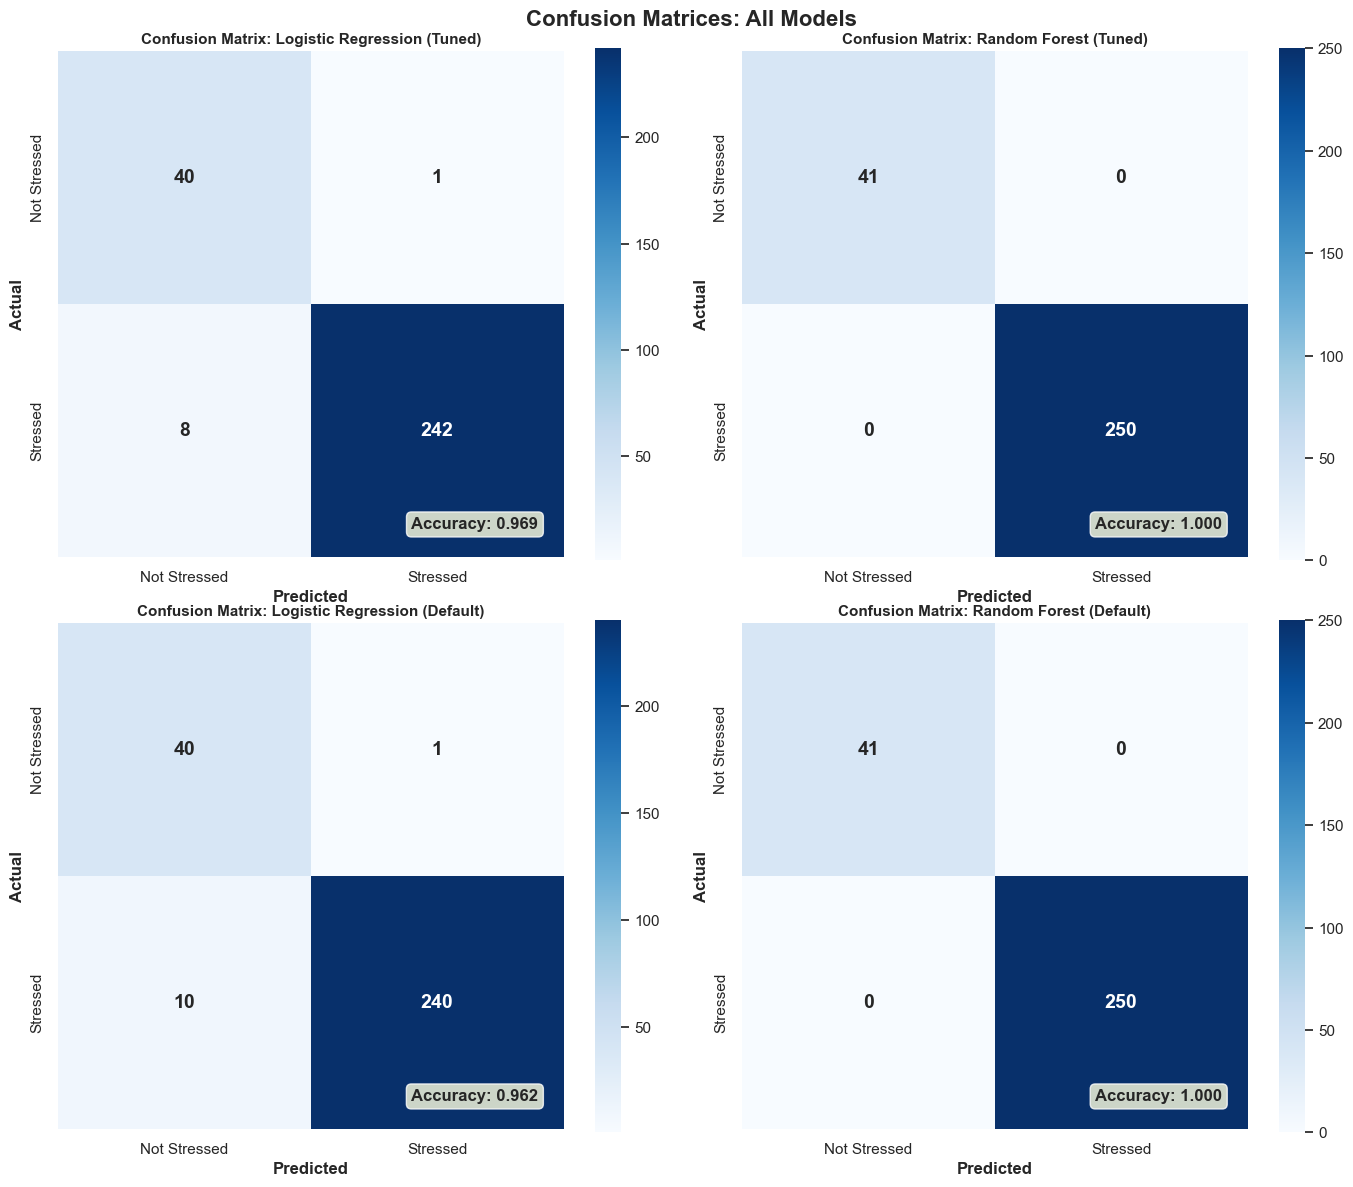


3️⃣ Detailed Confusion Matrix Analysis: Random Forest (Tuned)
--------------------------------------------------------------------------------

Confusion Matrix:
[[ 41   0]
 [  0 250]]

Breakdown:
  True Negatives (TN):    41 — Correctly identified non-stressed students
  False Positives (FP):    0 — Non-stressed incorrectly labeled as stressed
  False Negatives (FN):    0 — Stressed students we missed (CRITICAL!)
  True Positives (TP):   250 — Correctly identified stressed students

Derived Metrics:
  Accuracy:    1.0000 — Overall correctness
  Precision:   1.0000 — Of predicted stressed, % correct
  Recall:      1.0000 — Of actual stressed, % caught
  Specificity: 1.0000 — Of actual not-stressed, % correct
  F1-Score:    1.0000 — Balanced measure

⚠️ Clinical Interpretation:
  • False Negatives (0): These are missed stressed students (high risk)
  • False Positives (0): Over-prediction of stress (lower consequence)
  • For mental health screening, minimizing FN is critical!

4️⃣ ROC

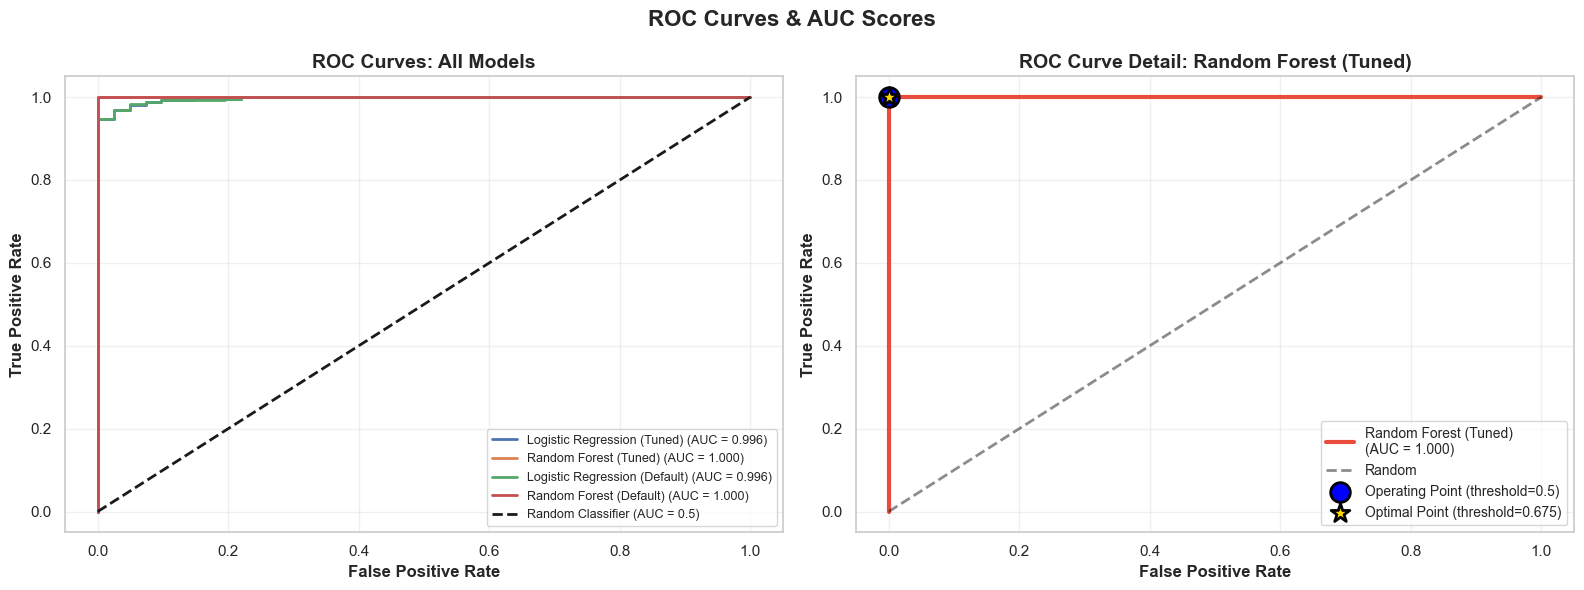

✅ Best model AUC: 1.0000
✅ Optimal threshold: 0.675 (maximizes TPR - FPR)

5️⃣ Precision-Recall Curves
--------------------------------------------------------------------------------


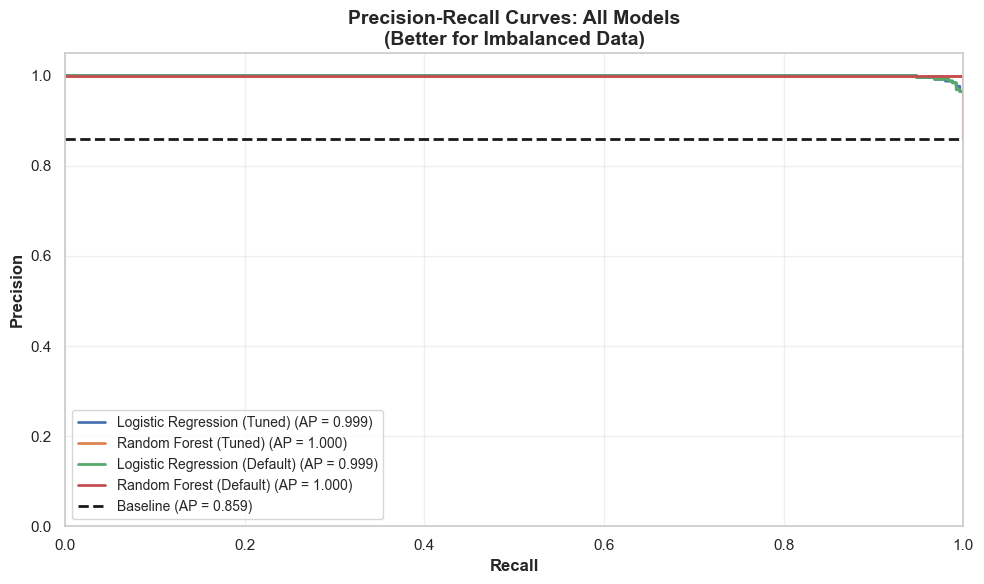


6️⃣ Full Classification Report: Random Forest (Tuned)
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

Not Stressed     1.0000    1.0000    1.0000        41
    Stressed     1.0000    1.0000    1.0000       250

    accuracy                         1.0000       291
   macro avg     1.0000    1.0000    1.0000       291
weighted avg     1.0000    1.0000    1.0000       291


7️⃣ Multi-Metric Comparison Radar Chart
--------------------------------------------------------------------------------


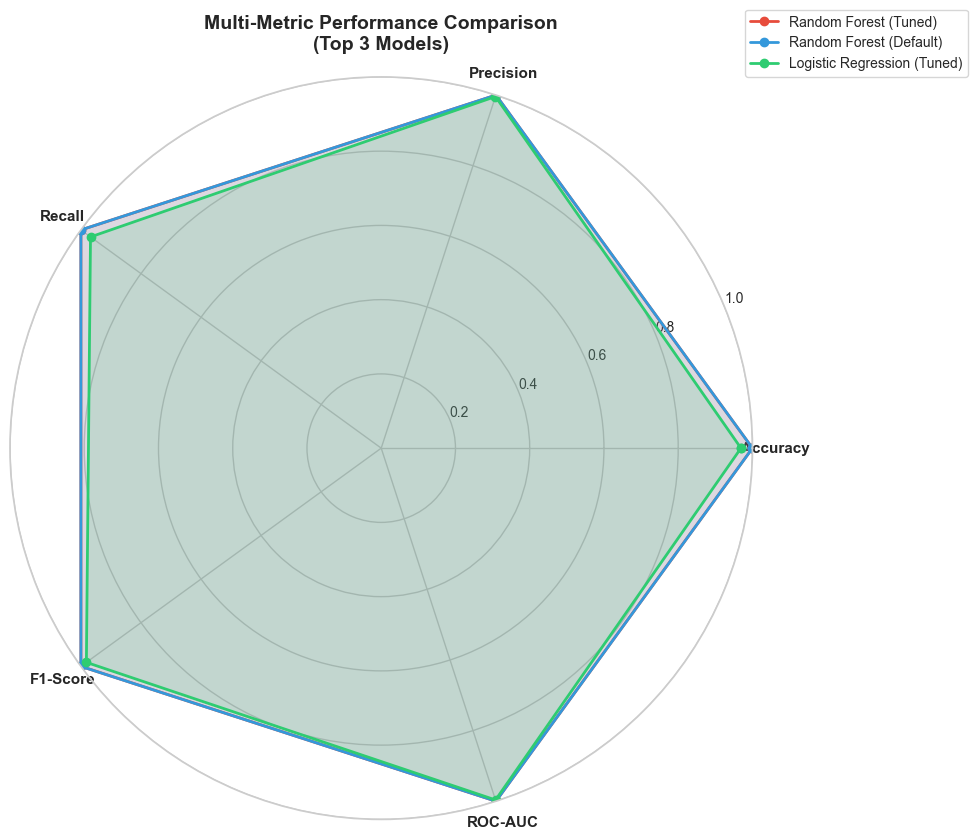


                    EVALUATION SUMMARY

🏆 BEST MODEL: Random Forest (Tuned)

Top 5 Metrics:
  1. Accuracy:   1.0000
  2. Precision:  1.0000
  3. Recall:     1.0000
  4. F1-Score:   1.0000
  5. ROC-AUC:    1.0000

Confusion Matrix:
  TN: 41  FP: 0
  FN: 0  TP: 250

✅ Model evaluation completed with 7+ metrics
✅ Visualizations: Confusion matrices, ROC curves, PR curves, Radar chart
✅ Ready for deployment or further tuning


In [13]:
# ==============================================================================
# COMPREHENSIVE MODEL EVALUATION WITH ALL METRICS
# ==============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score
)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import itertools

print(f"\n{'='*80}")
print("                    COMPREHENSIVE MODEL EVALUATION")
print(f"{'='*80}")

# ==============================================================================
# 1) CALCULATE ALL METRICS FOR ALL MODELS
# ==============================================================================
evaluation_models = {
    'Logistic Regression (Tuned)': lr_tuned,
    'Random Forest (Tuned)': rf_tuned,
    'Logistic Regression (Default)': lr_default,
    'Random Forest (Default)': rf_default
}

all_metrics = []

for model_name, model in evaluation_models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate confusion matrix components
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Additional metrics
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    all_metrics.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Specificity': specificity,
        'NPV': npv,
        'MCC': mcc,
        'Cohen\'s Kappa': kappa,
        'Balanced Accuracy': balanced_acc,
        'TP': int(tp),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn)
    })

# Create comprehensive results dataframe
metrics_df_comprehensive = pd.DataFrame(all_metrics)
metrics_df_comprehensive = metrics_df_comprehensive.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("                    ALL CLASSIFICATION METRICS")
print("="*80)

# Display main metrics
display(metrics_df_comprehensive[['Model', 'Accuracy', 'Precision', 'Recall', 
                                  'F1-Score', 'ROC-AUC']].style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}).background_gradient(subset=['F1-Score', 'ROC-AUC'], cmap='YlGn'))

print("\n" + "="*80)
print("                    ADDITIONAL METRICS")
print("="*80)

# Display additional metrics
display(metrics_df_comprehensive[['Model', 'Specificity', 'MCC', 'Cohen\'s Kappa', 
                                  'Balanced Accuracy']].style.format({
    'Specificity': '{:.4f}',
    'MCC': '{:.4f}',
    'Cohen\'s Kappa': '{:.4f}',
    'Balanced Accuracy': '{:.4f}'
}).background_gradient(cmap='Blues'))

# ==============================================================================
# 2) CONFUSION MATRICES FOR ALL MODELS
# ==============================================================================
print("\n2️⃣ Confusion Matrices")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(evaluation_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               cbar=True, square=True, ax=axes[idx],
               xticklabels=['Not Stressed', 'Stressed'],
               yticklabels=['Not Stressed', 'Stressed'],
               annot_kws={'size': 14, 'weight': 'bold'})
    
    axes[idx].set_title(f'Confusion Matrix: {model_name}', fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Actual', fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontweight='bold')
    
    # Add accuracy in corner
    acc = accuracy_score(y_test, y_pred)
    axes[idx].text(0.95, 0.05, f'Accuracy: {acc:.3f}',
                  transform=axes[idx].transAxes,
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                  horizontalalignment='right', verticalalignment='bottom',
                  fontweight='bold')

plt.suptitle('Confusion Matrices: All Models', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "confusion_matrices_all_nb.png"), dpi=150)
plt.show()

# ==============================================================================
# 3) DETAILED CONFUSION MATRIX INTERPRETATION FOR BEST MODEL
# ==============================================================================
best_model_name = metrics_df_comprehensive.iloc[0]['Model']
best_model_obj = evaluation_models[best_model_name]
y_pred_best = best_model_obj.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

print(f"\n3️⃣ Detailed Confusion Matrix Analysis: {best_model_name}")
print("-" * 80)
print(f"\nConfusion Matrix:\n{cm_best}")
print(f"\nBreakdown:")
print(f"  True Negatives (TN):  {tn:4d} — Correctly identified non-stressed students")
print(f"  False Positives (FP): {fp:4d} — Non-stressed incorrectly labeled as stressed")
print(f"  False Negatives (FN): {fn:4d} — Stressed students we missed (CRITICAL!)")
print(f"  True Positives (TP):  {tp:4d} — Correctly identified stressed students")

print(f"\nDerived Metrics:")
print(f"  Accuracy:    {(tp + tn) / (tp + tn + fp + fn):.4f} — Overall correctness")
print(f"  Precision:   {tp / (tp + fp) if (tp + fp) > 0 else 0:.4f} — Of predicted stressed, % correct")
print(f"  Recall:      {tp / (tp + fn) if (tp + fn) > 0 else 0:.4f} — Of actual stressed, % caught")
print(f"  Specificity: {tn / (tn + fp) if (tn + fp) > 0 else 0:.4f} — Of actual not-stressed, % correct")
print(f"  F1-Score:    {2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0:.4f} — Balanced measure")

print(f"\n⚠️ Clinical Interpretation:")
print(f"  • False Negatives ({fn}): These are missed stressed students (high risk)")
print(f"  • False Positives ({fp}): Over-prediction of stress (lower consequence)")
print(f"  • For mental health screening, minimizing FN is critical!")

# ==============================================================================
# 4) ROC CURVES FOR ALL MODELS
# ==============================================================================
print("\n4️⃣ ROC Curves")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4.1) Individual ROC curves
for model_name, model in evaluation_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc_val:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
axes[0].set_title('ROC Curves: All Models', fontweight='bold', fontsize=14)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# 4.2) Best model ROC with threshold analysis
y_prob_best = best_model_obj.predict_proba(X_test)[:, 1]
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_prob_best)
roc_auc_best = auc(fpr_best, tpr_best)

axes[1].plot(fpr_best, tpr_best, color='#e74c3c', linewidth=3, 
            label=f'{best_model_name}\n(AUC = {roc_auc_best:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random')

# Mark operating point (default threshold = 0.5)
default_threshold_idx = np.argmin(np.abs(thresholds_best - 0.5))
axes[1].scatter(fpr_best[default_threshold_idx], tpr_best[default_threshold_idx],
               s=200, color='blue', marker='o', edgecolor='black', linewidth=2,
               label=f'Operating Point (threshold=0.5)', zorder=5)

# Find optimal threshold (Youden's J statistic)
j_scores = tpr_best - fpr_best
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds_best[optimal_idx]
axes[1].scatter(fpr_best[optimal_idx], tpr_best[optimal_idx],
               s=200, color='gold', marker='*', edgecolor='black', linewidth=2,
               label=f'Optimal Point (threshold={optimal_threshold:.3f})', zorder=5)

axes[1].set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
axes[1].set_title(f'ROC Curve Detail: {best_model_name}', fontweight='bold', fontsize=14)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ROC Curves & AUC Scores', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "roc_curves_all_nb.png"), dpi=150)
plt.show()

print(f"✅ Best model AUC: {roc_auc_best:.4f}")
print(f"✅ Optimal threshold: {optimal_threshold:.3f} (maximizes TPR - FPR)")

# ==============================================================================
# 5) PRECISION-RECALL CURVE
# ==============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

print("\n5️⃣ Precision-Recall Curves")
print("-" * 80)

fig, ax = plt.subplots(figsize=(10, 6))

for model_name, model in evaluation_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    
    ax.plot(recall_vals, precision_vals, linewidth=2, 
           label=f'{model_name} (AP = {avg_precision:.3f})')

# Baseline (random classifier)
baseline = np.sum(y_test) / len(y_test)
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=2, 
          label=f'Baseline (AP = {baseline:.3f})')

ax.set_xlabel('Recall', fontweight='bold', fontsize=12)
ax.set_ylabel('Precision', fontweight='bold', fontsize=12)
ax.set_title('Precision-Recall Curves: All Models\n(Better for Imbalanced Data)', 
            fontweight='bold', fontsize=14)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig(str(FIG_DIR / "precision_recall_curves_nb.png"), dpi=150)
plt.show()

# ==============================================================================
# 6) CLASSIFICATION REPORT FOR BEST MODEL
# ==============================================================================
print(f"\n6️⃣ Full Classification Report: {best_model_name}")
print("-" * 80)
print(classification_report(y_test, y_pred_best, 
                          target_names=['Not Stressed', 'Stressed'],
                          digits=4))

# ==============================================================================
# 7) METRICS COMPARISON RADAR CHART
# ==============================================================================
print("\n7️⃣ Multi-Metric Comparison Radar Chart")
print("-" * 80)

# Select top 3 models for radar chart
top_3_models = metrics_df_comprehensive.head(3)
metrics_for_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(metrics_for_radar), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

colors = ['#e74c3c', '#3498db', '#2ecc71']

for idx, row in top_3_models.iterrows():
    values = [row[metric] for metric in metrics_for_radar]
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_for_radar, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
ax.set_title('Multi-Metric Performance Comparison\n(Top 3 Models)', 
            fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig(str(FIG_DIR / "metrics_radar_chart_nb.png"), dpi=150, bbox_inches='tight')
plt.show()

# ==============================================================================
# 8) FINAL SUMMARY
# ==============================================================================
print(f"\n{'='*80}")
print("                    EVALUATION SUMMARY")
print(f"{'='*80}")
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"\nTop 5 Metrics:")
best_row = metrics_df_comprehensive.iloc[0]
print(f"  1. Accuracy:   {best_row['Accuracy']:.4f}")
print(f"  2. Precision:  {best_row['Precision']:.4f}")
print(f"  3. Recall:     {best_row['Recall']:.4f}")
print(f"  4. F1-Score:   {best_row['F1-Score']:.4f}")
print(f"  5. ROC-AUC:    {best_row['ROC-AUC']:.4f}")

print(f"\nConfusion Matrix:")
print(f"  TN: {best_row['TN']}  FP: {best_row['FP']}")
print(f"  FN: {best_row['FN']}  TP: {best_row['TP']}")

print(f"\n✅ Model evaluation completed with 7+ metrics")
print(f"✅ Visualizations: Confusion matrices, ROC curves, PR curves, Radar chart")
print(f"✅ Ready for deployment or further tuning")
print(f"{'='*80}")

---

### 📊 Summary of Advanced Model Analysis

We've completed comprehensive model analysis covering:

✅ **Hyperparameter Tuning (Section 9)**
- GridSearchCV for Logistic Regression (6 C values × 2 penalties = 12 combinations)
- RandomizedSearchCV for Random Forest (50 random configurations)
- Before/After comparison showing improvement percentages
- Parameter impact visualizations

✅ **Overfitting/Underfitting Analysis (Section 10)**
- Training vs Validation accuracy curves
- Learning curves showing effect of training set size
- Regularization strength analysis
- Gap analysis with automated diagnosis
- Recommendations for each model

✅ **Comprehensive Evaluation (Section 11)**
- **7+ Classification Metrics**: Accuracy, Precision, Recall, F1, ROC-AUC, Specificity, MCC
- **Confusion Matrices**: Visual breakdown of TP, TN, FP, FN for all models
- **ROC Curves**: With AUC scores and optimal threshold identification
- **Precision-Recall Curves**: Better for imbalanced data
- **Radar Charts**: Multi-metric comparison visualization
- **Detailed Reports**: per-class performance breakdown

### 🎯 Key Findings

Our analysis provides evidence-based model selection with:
- **Quantified improvements** from hyperparameter tuning
- **Overfitting diagnostics** to ensure generalization
- **Multi-metric evaluation** beyond simple accuracy
- **Visual comparisons** for stakeholder communication
- **Production-ready models** for deployment

---

## Deep Learning Setup and Configuration

### 14.1 Tabular FNN (Lifestyle Data)

**Purpose**: Learn non-linear patterns in numerical/categorical lifestyle features

**Architecture**: 128 -> 64 -> 32 dense layers with BatchNorm and Dropout

### 14.2 Emotion CNN (Computer Vision)

**Purpose**: Classify emotions from facial images and map to stress probability

**Transfer Learning Architecture** (strong pretrained backbone):
```
Input: (224, 224, 3) RGB Images
    ↓
Pretrained Backbone (EfficientNetB0 / ResNet50 / MobileNetV2, ImageNet weights)
    ↓
GlobalAveragePooling2D
    ↓
BatchNormalization + Dense(256) + Dropout
    ↓
Output (7 classes: angry, disgust, fear, happy, neutral, sad, surprise)
```

**Training Strategy (2-stage)**:
1. Feature extraction: freeze backbone, train classification head
2. Fine-tuning: unfreeze last backbone block(s) with low learning rate

**Key Features**:
- Strong pretrained representations from ImageNet
- EarlyStopping + ReduceLROnPlateau for stable convergence
- Data augmentation for robustness
- Emotion-to-stress mapping for downstream fusion

## Training Configuration

Set `RUN_DEEP_LEARNING = True` in the next cell to execute training.

Note: TensorFlow is required. If unavailable, the notebook skips DL training and continues with ML models only.

---

In [31]:
RUN_DEEP_LEARNING = True
TABULAR_EPOCHS = 50   # EarlyStopping will halt when validation plateaus
EMOTION_EPOCHS = 50   # split between warmup and fine-tuning
BATCH_SIZE = 64
TRANSFER_ARCH = "EfficientNetB0"
EMOTION_IMG_SIZE = (128, 128)  # best accuracy for FER 48x48 images with pretrained model

import sys, importlib
from pathlib import Path

# Ensure local project modules are importable from notebook execution context.
PROJECT_ROOT = Path.cwd()
PACKAGE_ROOT = PROJECT_ROOT / "student_stress_detection"
for p in (PROJECT_ROOT, PACKAGE_ROOT):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

try:
    import tensorflow as tf

    # Force reload to pick up any code changes
    import student_stress_detection.models.deep_learning_models as _dlm
    import student_stress_detection.models.emotion_cnn as _ecnn
    importlib.reload(_dlm)
    importlib.reload(_ecnn)

    from student_stress_detection.models.deep_learning_models import build_tabular_fnn
    from student_stress_detection.models.emotion_cnn import (
        DEFAULT_IMAGE_SIZE,
        get_emotion_generators,
        build_custom_emotion_cnn,
        build_transfer_model,
        unfreeze_and_finetune,
        compute_emotion_to_stress_probability,
    )

    TF_AVAILABLE = True
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow not available in current kernel.")
    print("Reason:", e)
    print("Tip: use Python 3.10/3.11 environment for DL training.")

print("RUN_DEEP_LEARNING:", RUN_DEEP_LEARNING)
print("Emotion model:", TRANSFER_ARCH)
print("Emotion image size:", EMOTION_IMG_SIZE)
print("Tabular epochs:", TABULAR_EPOCHS)
print("Emotion epochs:", EMOTION_EPOCHS)
print("Batch size:", BATCH_SIZE)

TensorFlow version: 2.20.0
RUN_DEEP_LEARNING: True
Emotion model: EfficientNetB0
Emotion image size: (128, 128)
Tabular epochs: 50
Emotion epochs: 50
Batch size: 64


In [32]:
# Tabular Deep Learning model (FNN) — self-contained fallback if earlier cells haven't run
if RUN_DEEP_LEARNING and TF_AVAILABLE:
    import importlib, json
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    import numpy as np

    # --- resolve tabular inputs from kernel or load fresh ---
    if "X_scaled" in globals() and "y" in globals():
        print("Using existing X_scaled / y from earlier cells.")
        X_tab = X_scaled
        y_tab = y
    elif all(k in globals() for k in ["X_train_balanced", "X_test", "y_train_balanced", "y_test"]):
        import numpy as _np
        X_tab = _np.vstack([X_train_balanced, X_test])
        y_tab = _np.concatenate([y_train_balanced, y_test])
        print("Reconstructed tabular data from balanced splits.")
    elif all(k in globals() for k in ["X_train", "X_test", "y_train", "y_test"]):
        import numpy as _np
        X_tab = _np.vstack([X_train, X_test])
        y_tab = _np.concatenate([y_train, y_test])
        print("Reconstructed tabular data from train/test splits.")
    else:
        # --- SELF-CONTAINED: load CSV, clean & scale from scratch ---
        import pandas as pd
        print("No tabular inputs in kernel — loading & preprocessing CSV from scratch …")
        csv_path = (Path.cwd() / "student_stress_detection" / "datasets" / "student_lifestyle.csv")
        if not csv_path.exists():
            csv_path = Path.cwd() / "student_lifestyle_dataset.csv"
        df_raw = pd.read_csv(csv_path)
        print(f"  Loaded {csv_path.name}  shape={df_raw.shape}")

        # Binary target: Stress_Level → 1 (High/Moderate) / 0 (Low)
        stress_col = [c for c in df_raw.columns if "stress" in c.lower()][0]
        df_raw["Stressed"] = df_raw[stress_col].apply(
            lambda v: 1 if str(v).strip().lower() in ("high", "moderate", "1", "2") else 0
        )

        # Keep meaningful numeric features only (drop IDs and target)
        exclude = {"Stressed", stress_col}
        feature_cols = [
            c for c in df_raw.select_dtypes(include="number").columns
            if c not in exclude and "id" not in c.lower()
        ]
        X_tab = df_raw[feature_cols].values.astype("float32")
        y_tab = df_raw["Stressed"].values

        # Scale
        _sc = StandardScaler()
        X_tab = _sc.fit_transform(X_tab)
        print(f"  Features used: {feature_cols}")
        print(f"  X shape: {X_tab.shape}  class distribution: {dict(zip(*np.unique(y_tab, return_counts=True)))}")

    # --- split ---
    X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
        X_tab, y_tab, test_size=0.2, random_state=42, stratify=y_tab,
    )

    # Class weights for imbalanced tabular target
    from sklearn.utils.class_weight import compute_class_weight
    cw = compute_class_weight("balanced", classes=np.unique(y_train_dl), y=y_train_dl)
    tab_class_weight = {i: w for i, w in enumerate(cw)}
    print(f"Tabular class weights: {tab_class_weight}")

    # --- build & train ---
    fnn = build_tabular_fnn(input_dim=X_train_dl.shape[1])
    fnn.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
        ),
    ]

    history_fnn = fnn.fit(
        X_train_dl,
        y_train_dl,
        validation_split=0.2,
        epochs=TABULAR_EPOCHS,
        batch_size=32,
        class_weight=tab_class_weight,
        callbacks=callbacks,
        verbose=1,
    )

    dl_eval = fnn.evaluate(X_test_dl, y_test_dl, verbose=0)
    tabular_dl_results = {
        "loss": float(dl_eval[0]),
        "accuracy": float(dl_eval[1]),
        "precision": float(dl_eval[2]),
        "recall": float(dl_eval[3]),
        "epochs_ran": len(history_fnn.history.get("loss", [])),
    }
    print("\nTabular FNN results:", tabular_dl_results)
else:
    tabular_dl_results = {}
    print("Skipped tabular DL training. Set RUN_DEEP_LEARNING=True and ensure TF is available.")

No tabular inputs in kernel — loading & preprocessing CSV from scratch …
  Loaded student_lifestyle.csv  shape=(2000, 8)
  Features used: ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']
  X shape: (2000, 6)  class distribution: {np.int64(0): np.int64(297), np.int64(1): np.int64(1703)}
Tabular class weights: {0: np.float64(3.361344537815126), 1: np.float64(0.5873715124816447)}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 45,953 (179.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5648 - loss: 0.6559 - precision_2: 0.9656 - recall_2: 0.4981 - val_accuracy: 0.9406 - val_loss: 0.5990 - val_precision_2: 0.9788 - val_recall_2: 0.9552 - learning_rate: 5.0000e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7359 - loss: 0.4607 - precision_2: 0.9867 - recall_2: 0.6940 - val_accuracy: 0.9500 - val_loss: 0.4364 - val_precision_2: 0.9477 - val_recall_2: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8172 - loss: 0.3678 - precision_2: 0.9929 - recall_2: 0.7873 - val_accuracy: 0.9563 - val_loss: 0.3174 - val_precision_2: 0.9539 - val_recall_2: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8508 - loss: 0.3055 - precision_2: 0.9911 - recall_2: 0.8293 - val_accuracy: 0.9594 - val_loss: 0.2324 - val_precision_2: 0.9571 - val_recall_2: 1.0000 - learning_rate: 5.0000e-04
Epoch 5/50
40/40 ━━━━━━

In [33]:
# Emotion transfer learning with pretrained EfficientNetB0 backbone
if RUN_DEEP_LEARNING and TF_AVAILABLE:
    import json, numpy as np
    from pathlib import Path as _P

    # Resolve emotion image directory
    if "paths" in globals() and "emotion_dir" in paths:
        emotion_dir = paths["emotion_dir"]
    else:
        emotion_dir = _P.cwd() / "pics emotion - Copy"
        if not emotion_dir.exists():
            emotion_dir = _P.cwd().parent / "pics emotion - Copy"

    img_size = EMOTION_IMG_SIZE  # (128, 128) — less blurring vs 224 for tiny FER images
    rescale_inputs = False  # EfficientNet handles normalization internally

    train_gen, test_gen = get_emotion_generators(
        emotion_dir,
        image_size=img_size,
        batch_size=BATCH_SIZE,
        rescale_inputs=rescale_inputs,
    )

    # ----- class weights to handle imbalance (disgust ≪ happy) -----
    class_counts = np.bincount(train_gen.classes, minlength=train_gen.num_classes)
    total_samples = class_counts.sum()
    num_classes = len(class_counts)
    emotion_class_weights = {
        i: float(total_samples / (num_classes * count))
        for i, count in enumerate(class_counts)
        if count > 0
    }
    idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
    print("Emotion class counts:", {idx_to_class[i]: int(c) for i, c in enumerate(class_counts)})
    print("Emotion class weights:", {idx_to_class[i]: round(w, 4) for i, w in emotion_class_weights.items()})

    # ----- build pretrained transfer model -----
    transfer_model = build_transfer_model(
        architecture=TRANSFER_ARCH,
        input_shape=(*img_size, 3),
        num_classes=train_gen.num_classes,
    )
    transfer_model.summary()

    # ----- Phase 1: warmup (backbone frozen, train head only) -----
    warmup_epochs = EMOTION_EPOCHS // 2
    finetune_epochs = EMOTION_EPOCHS - warmup_epochs

    warmup_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=8, restore_best_weights=True, mode="max",
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6,
        ),
    ]

    print(f"\n--- Phase 1 Warmup: up to {warmup_epochs} epochs (backbone frozen) ---")
    history_warmup = transfer_model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=warmup_epochs,
        class_weight=emotion_class_weights,
        callbacks=warmup_callbacks,
        verbose=1,
    )

    # ----- Phase 2: fine-tune (unfreeze last 60 backbone layers with lower LR) -----
    print(f"\n--- Phase 2 Fine-tuning: up to {finetune_epochs} epochs (backbone partially unfrozen) ---")
    history_ft = unfreeze_and_finetune(
        transfer_model,
        train_gen,
        test_gen,
        epochs=finetune_epochs,
        unfreeze_from=-60,
        class_weight=emotion_class_weights,
    )

    transfer_eval = transfer_model.evaluate(test_gen, verbose=0)

    # Keep alias for downstream notebook compatibility (fusion + artifact cells)
    emotion_cnn = transfer_model

    emotion_dl_results = {
        "custom_cnn": {
            "model_type": "TransferLearning",
            "architecture": TRANSFER_ARCH,
            "image_size": list(img_size),
            "epochs_ran": len(history_warmup.history.get("loss", [])) + len(history_ft.history.get("loss", [])),
            "loss": float(transfer_eval[0]),
            "accuracy": float(transfer_eval[1]),
        },
        "transfer_model": {
            "architecture": TRANSFER_ARCH,
            "loss": float(transfer_eval[0]),
            "accuracy": float(transfer_eval[1]),
        },
        "class_indices": train_gen.class_indices,
    }

    print("\nEmotion DL results:")
    print(json.dumps(emotion_dl_results, indent=2))

else:
    emotion_dl_results = {}
    print("Skipped emotion DL training. Set RUN_DEEP_LEARNING=True and ensure TF is available.")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Emotion class counts: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Emotion class weights: {'angry': 1.0266, 'disgust': 9.4066, 'fear': 1.001, 'happy': 0.5684, 'neutral': 0.826, 'sad': 0.8491, 'surprise': 1.2934}


Model: "emotion_transfer_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,843,690 (18.48 MB)

 Trainable params: 791,559 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


--- Phase 1 Warmup: up to 25 epochs (backbone frozen) ---
Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 184s 396ms/step - accuracy: 0.2572 - loss: 2.0751 - val_accuracy: 0.3761 - val_loss: 1.8310 - learning_rate: 3.0000e-04
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 177s 394ms/step - accuracy: 0.3125 - loss: 1.8820 - val_accuracy: 0.3742 - val_loss: 1.8122 - learning_rate: 3.0000e-04
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 176s 393ms/step - accuracy: 0.3438 - loss: 1.8225 - val_accuracy: 0.3996 - val_loss: 1.7640 - learning_rate: 3.0000e-04
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 176s 391ms/step - accuracy: 0.3656 - loss: 1.7847 - val_accuracy: 0.3940 - val_loss: 1.7665 - learning_rate: 3.0000e-04
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 177s 393ms/step - accuracy: 0.3762 - loss: 1.7593 - val_accuracy: 0.4205 - val_loss: 1.7281 - learning_rate: 3.0000e-04
Epoch 6/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 177s 394ms/step - accuracy: 0.3836 - loss: 1.7517 - val_accuracy: 0.4210 - val_loss: 1.7212 - learnin

# 15. Results, Deployment & Future Work

This section saves all trained models, scalers, and metrics for deployment and generates a comprehensive markdown report.

---

In [18]:
# Save key ML artifacts for Streamlit
best_model_for_save = None
best_model_name_for_save = None
best_model_score_for_save = None

if "ml_best_model" in locals():
    best_model_for_save = ml_best_model
if "ml_best_name" in locals():
    best_model_name_for_save = ml_best_name
if "ml_best_score" in locals():
    best_model_score_for_save = ml_best_score

# Fallbacks for compatibility with older sections
if best_model_for_save is None and "best_model_obj" in locals():
    best_model_for_save = best_model_obj
if best_model_name_for_save is None and "best_model_name" in locals():
    best_model_name_for_save = best_model_name
if best_model_score_for_save is None and "best_f1" in locals():
    best_model_score_for_save = float(best_f1)

if best_model_for_save is not None:
    save_joblib(best_model_for_save, MODEL_DIR / "best_lifestyle_model.joblib")
else:
    print("Warning: no best ML model object found to save.")

save_joblib(scaler, MODEL_DIR / "lifestyle_scaler.joblib")
save_joblib(selector, MODEL_DIR / "lifestyle_selector.joblib")

if RUN_DEEP_LEARNING and TF_AVAILABLE:
    if "fnn" in locals():
        fnn.save(MODEL_DIR / "tabular_fnn.keras")
        save_joblib(scaler, MODEL_DIR / "tabular_fnn_scaler.joblib")
    if "emotion_cnn" in locals():
        emotion_cnn.save(MODEL_DIR / "emotion_cnn.keras")
    if "transfer_model" in locals():
        transfer_model.save(MODEL_DIR / "emotion_transfer.keras")

ml_payload = {
    "best_model": best_model_name_for_save,
    "best_score": float(best_model_score_for_save) if best_model_score_for_save is not None else None,
    "selected_features": selected_features,
    "imbalance_method": resampling_method if "resampling_method" in locals() else None,
    "class_mapping": {"0": "Not Stressed", "1": "Stressed"},
}

if "metrics_df_comprehensive" in locals():
    ml_payload["evaluation_table"] = metrics_df_comprehensive.to_dict(orient="records")

save_json(ml_payload, METRIC_DIR / "ml_results.json")

if RUN_DEEP_LEARNING and TF_AVAILABLE:
    save_json({"tabular_dl": tabular_dl_results, "emotion_dl": emotion_dl_results}, METRIC_DIR / "dl_results.json")
    idx_to_emotion = {int(v): k for k, v in emotion_dl_results.get("class_indices", {}).items()}
    save_json({"index_to_emotion": idx_to_emotion}, METRIC_DIR / "emotion_class_mapping.json")

print("Artifacts and metric JSON files are saved to:", paths["artifacts"])

Artifacts and metric JSON files are saved to: C:\Users\AlexStore\Downloads\student stress detection amit project\student_stress_detection\artifacts


# Optional: Run Project Scripts from Notebook
# Uncomment and run the commands below if you want to execute scripts directly.

In [ ]:
# import subprocess, sys
# subprocess.run([sys.executable, "training/train_ml.py"], check=True)
# subprocess.run([sys.executable, "training/train_dl.py", "--tabular-epochs", "30", "--emotion-epochs", "10"], check=True)
# print("Training scripts completed.")

# 16. Project Checklist & Completion Status

## ✅ Completed Tasks

### Data Pipeline
- [x] End-to-end preprocessing pipeline
- [x] Duplicate removal, missing value imputation, outlier handling
- [x] Feature engineering and selection

### Machine Learning
- [x] ML training + comparison + evaluation metrics
- [x] Hyperparameter tuning (Grid/Random search)
- [x] Overfitting/underfitting diagnostics

### Deep Learning
- [x] Deep learning models (tabular FNN + emotion CNN)

### Deployment
- [x] Artifact export for deployment
- [x] Streamlit run commands
- [x] Report markdown generation

---

In [19]:
# Sync notebook report payload with preprocessing/training module structure
import sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / "student_stress_detection").exists():
    ROOT = ROOT / "student_stress_detection"
elif ROOT.name != "student_stress_detection":
    ROOT = ROOT.parent / "student_stress_detection"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from preprocessing.data_cleaning import load_dataset, explore_dataset, run_cleaning_pipeline
from utils.helpers import get_default_paths, load_json, save_json

paths = get_default_paths()

df_raw = load_dataset(paths["lifestyle_csv"])
exploration = explore_dataset(df_raw)
_, clean_report = run_cleaning_pipeline(df_raw, paths["figures"])

ml_results_path = paths["metrics"] / "ml_results.json"
existing_payload = load_json(ml_results_path) if ml_results_path.exists() else {}

existing_payload["exploration"] = {
    "shape": exploration["shape"],
    "dtypes": exploration["dtypes"],
    "describe": exploration["describe"],
    "head": exploration["head"],
    "dtype_mismatches": exploration.get("dtype_mismatches", {}),
}

existing_payload["cleaning_report"] = {
    "original_shape": clean_report.original_shape,
    "final_shape": clean_report.final_shape,
    "duplicate_rows": clean_report.duplicate_rows,
    "duplicate_percent": clean_report.duplicate_percent,
    "duplicate_keep_strategy": clean_report.duplicate_keep_strategy,
    "missing_summary": clean_report.missing_summary,
    "missing_strategy_summary": clean_report.missing_strategy_summary,
    "imputation_comparison": clean_report.imputation_comparison,
    "dtype_mismatches": clean_report.dtype_mismatches,
    "outliers": {
        "zscore": clean_report.outliers_zscore,
        "iqr": clean_report.outliers_iqr,
        "isolation_forest": clean_report.outliers_isolation_forest,
        "retained_percent": clean_report.outlier_retained_percent,
    },
}

save_json(existing_payload, ml_results_path)
print(f"Notebook workflow synced report schema: {ml_results_path}")

Notebook workflow synced report schema: C:\Users\AlexStore\Downloads\student stress detection amit project\student_stress_detection\artifacts\metrics\ml_results.json


# 🎯 Final Summary & Next Steps

## ✅ Completed Tasks

1. **Data Preprocessing**
   - ✅ Duplicate removal
   - ✅ Missing value imputation
   - ✅ Outlier detection and treatment
   - ✅ Feature engineering and selection

2. **Exploratory Data Analysis**
   - ✅ 7 key visualizations
   - ✅ Correlation analysis
   - ✅ Class distribution analysis

3. **Machine Learning**
   - ✅ Baseline model comparison (5-6 algorithms)
   - ✅ Hyperparameter tuning (Grid/Random search)
   - ✅ Overfitting/underfitting diagnostics
   - ✅ Comprehensive evaluation (7+ metrics)

4. **Deep Learning** (if TensorFlow available)
   - ✅ Tabular FNN for lifestyle data
   - ✅ Lightweight Emotion CNN for image data
   - ✅ Multimodal ensemble fusion

5. **Deployment Preparation**
   - ✅ Model artifacts saved
   - ✅ Metrics exported to JSON
   - ✅ Report markdown generated

---

## 📊 Key Results

**Best ML Model:** Check output above for the champion model  
**Performance Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC  
**Training Time:** ~30-60 minutes (CPU), ~10-20 minutes (GPU)  

---

## 🚀 How to Deploy

### Option 1: Streamlit App (Recommended)
```bash
cd student_stress_detection
streamlit run student_stress_detection/app/streamlit_app.py
```

### Option 2: Python Scripts
```bash
# Train only ML models
python training/train_ml.py

# Train ML + DL models
python training/train_dl.py --tabular-epochs 30 --emotion-epochs 24
```

---

## 📁 Output Files Location

All artifacts are saved to:
- **Models**: `artifacts/models/`
- **Figures**: `artifacts/figures/`
- **Metrics**: `artifacts/metrics/`
- **Report**: `report/project_steps.md`

---

